# <font color=' palegreen'>Data Science CA4</font>

<font color='palegreen'>Aidin Kazemi: 810101561</font>

<font color='palegreen'>Ali Zilouchi: 810101560</font>

<font color='palegreen'>Paria Pasehvarz: 810101393</font>

##<font color='orange'>**Task 1: MLP**</font>



First, we import necessary modules.

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, QuantileTransformer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import random
from imblearn.over_sampling import SMOTE
from collections import defaultdict, Counter

### <font color='skyblue'>1. Dataset Loading</font>


We download the datasets.

In [ ]:
import os

if not os.path.exists("dataset_flag"):
  !gdown 1-dPkb8hF0QjjNntvwBhclqE2s960_3DI
  !gdown 1RlJGTR_nSo8zY7Ut42oVmIOen9HxT0zU
  !touch dataset_flag

df = pd.read_csv("matches.csv")

Downloading...
From: https://drive.google.com/uc?id=1-dPkb8hF0QjjNntvwBhclqE2s960_3DI
To: /content/Fifa_world_cup_matches.csv
100% 19.5k/19.5k [00:00<00:00, 69.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1RlJGTR_nSo8zY7Ut42oVmIOen9HxT0zU
To: /content/matches.csv
100% 1.77M/1.77M [00:00<00:00, 14.0MB/s]


### <font color='skyblue'>2. EDA</font>


We load the look dataset and find out the shape and overall view and also search for any missing values to handle.

In [ ]:
print("📊 DataFrame Info:")
print(df.info())

print("\n🔍 First 5 Rows:")
print(df.head())

print("\n🧼 Missing Values:")
print(df.isnull().sum())

📊 DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17812 entries, 0 to 17811
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            17812 non-null  int64  
 1   home_team             17812 non-null  object 
 2   home_goals            17812 non-null  int64  
 3   away_goals            17812 non-null  int64  
 4   away_team             17812 non-null  object 
 5   wcm                   17812 non-null  int64  
 6   dif_inter_match       17812 non-null  float64
 7   dif_inter_match_won   17812 non-null  float64
 8   dif_inter_match_lost  17812 non-null  float64
 9   dif_inter_match_tie   17812 non-null  float64
 10  dif_inter_goals_sco   17812 non-null  float64
 11  dif_inter_goals_con   17812 non-null  float64
 12  dif_wc_match          17812 non-null  float64
 13  dif_wc_match_won      17812 non-null  float64
 14  dif_wc_match_lost     17812 non-null  float64
 15  d

Here we plot distributions of our features and target and also see their statistics.

📊 Summary Statistics for Numeric Features:
         Unnamed: 0           wcm  dif_inter_match  dif_inter_match_won  \
count  17812.000000  17812.000000     17812.000000         17812.000000   
mean    8905.500000      0.050528        39.204188            24.746407   
std     5142.025833      0.219037       494.412966           285.691530   
min        0.000000      0.000000      -966.000000          -578.000000   
25%     4452.750000      0.000000      -458.000000          -242.000000   
50%     8905.500000      0.000000        62.000000            60.000000   
75%    13358.250000      0.000000       503.000000           268.000000   
max    17811.000000      1.000000       966.000000           578.000000   

       dif_inter_match_lost  dif_inter_match_tie  dif_inter_goals_sco  \
count          17812.000000         17812.000000         17812.000000   
mean               6.269313             8.188468            85.072086   
std              118.601085           117.721027          1007

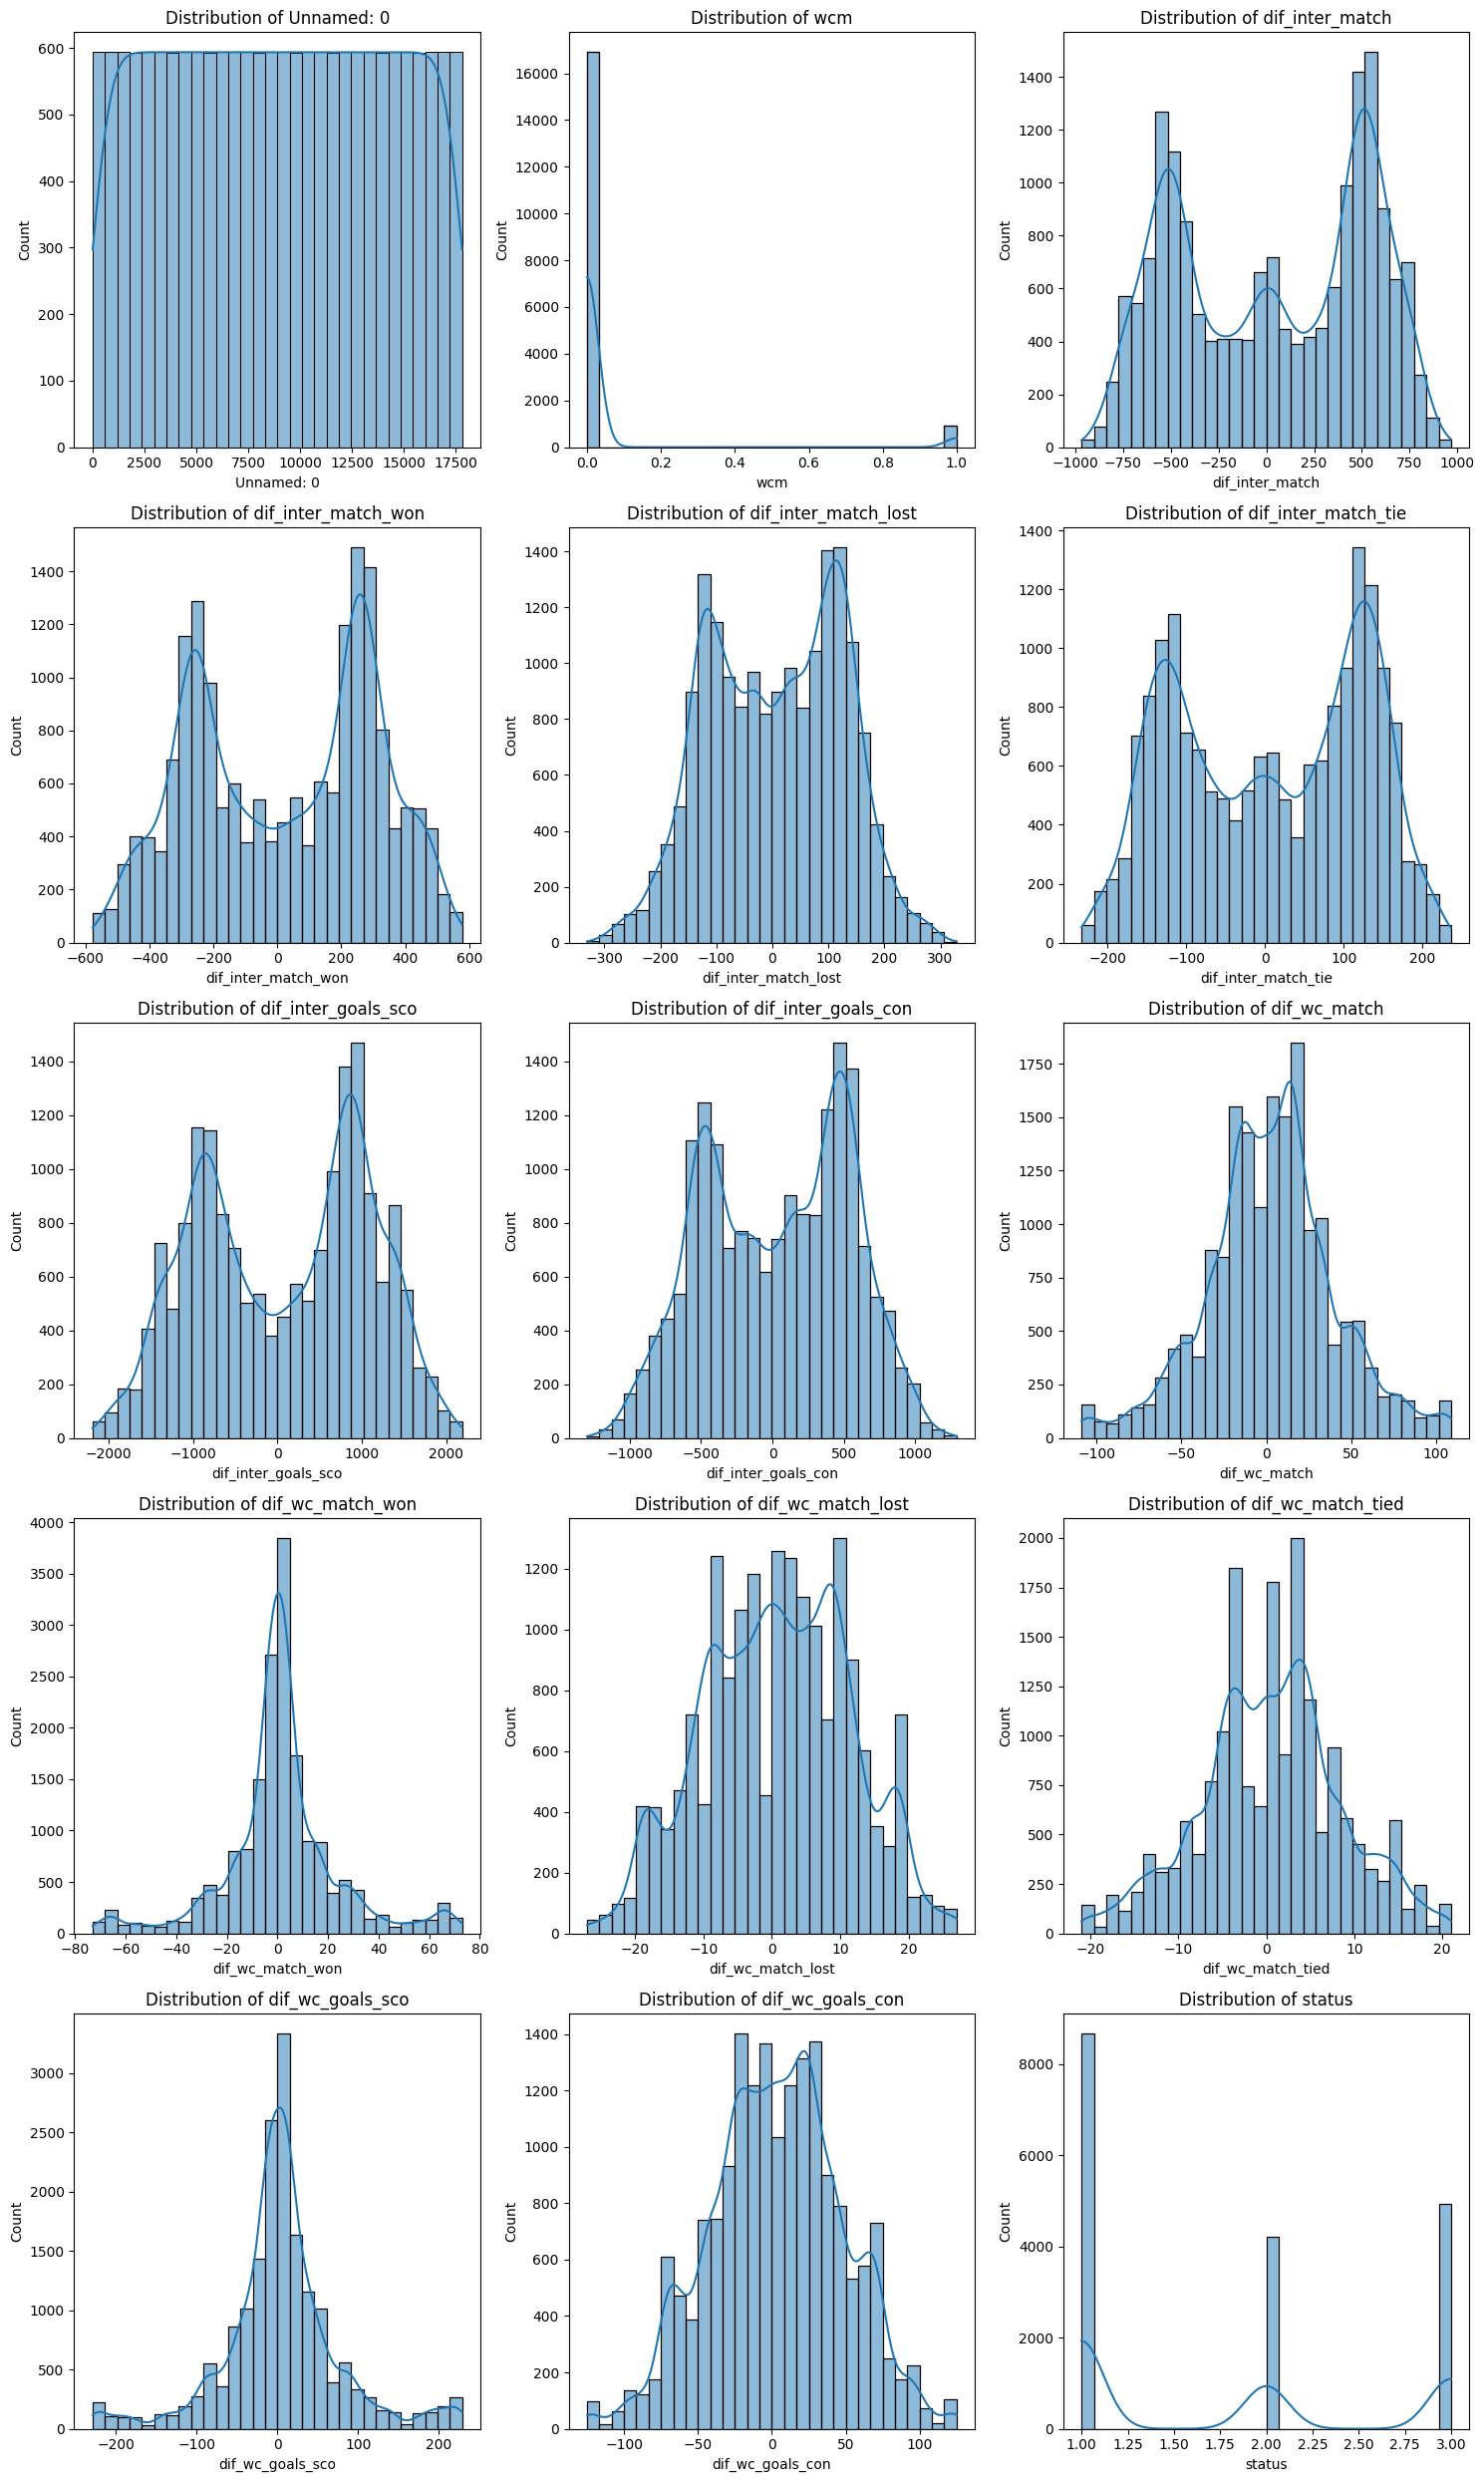

In [ ]:
numeric_features = df.select_dtypes(include=['int64', 'float64']).drop(columns=['home_goals', 'away_goals'], errors='ignore')

print("📊 Summary Statistics for Numeric Features:")
print(numeric_features.describe())

print("\n📈 Feature Distributions:")
plt.figure(figsize=(15, 25))
for i, column in enumerate(numeric_features.columns):
    plt.subplot((len(numeric_features.columns) + 2) // 3, 3, i + 1)
    sns.histplot(df[column], kde=True, bins=30)
    plt.title(f'Distribution of {column}')
    plt.tight_layout()
plt.show()

Finally, we plot correlation matrix of the dataset.

🔗 Correlation Heatmap:


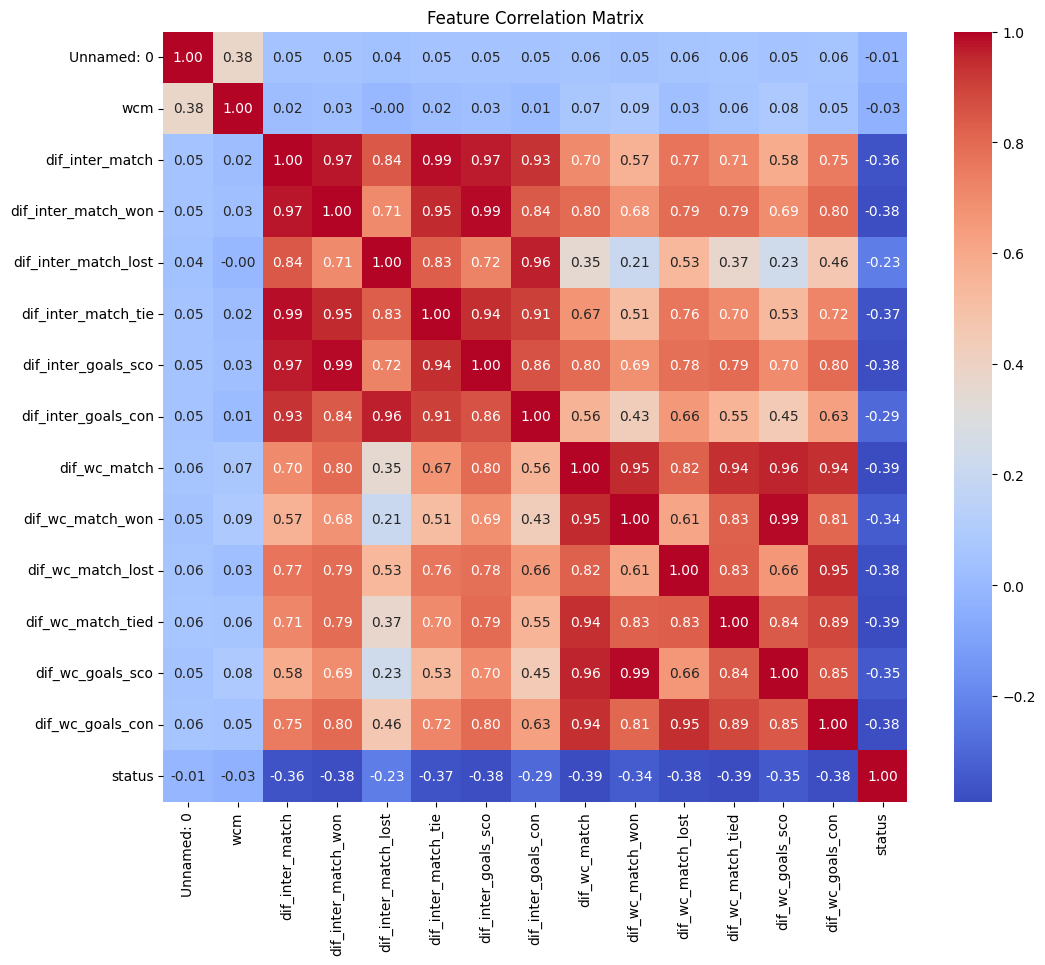

In [ ]:
print("🔗 Correlation Heatmap:")
plt.figure(figsize=(12, 10))
corr = numeric_features.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

### <font color='skyblue'>3. Data Preparation</font>


We eliminate some columns according to what told in project and seperate label.

In [ ]:
qualifiers = df[df['wcm'] == 0]

X = qualifiers.drop(columns=['home_team', 'home_goals', 'away_goals', 'away_team', 'status', 'wcm', 'Unnamed: 0'])
y = qualifiers['status']

Label Encoding

In [ ]:
y_encoder = LabelEncoder()
y = y_encoder.fit_transform(y)

We do the train-test split, with stratify setting we ensure proportion of classes in y is maintained in both the training and test sets.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=2)

Here since our dataset is imbalanced, we balance it by additional data points using SMOTE.

In [ ]:
smote = SMOTE(random_state=2)
X_train, y_train = smote.fit_resample(X_train, y_train)

Feature Scaling

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Convert to PyTorch tensors

In [ ]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

### <font color='skyblue'>4. Model Definition</font>


We define our MLP model here.

It contains linear, relu, sigmoid and batch normalization layers, also it has dropout in some layers for more generalization.

In [ ]:
class MLPModel(nn.Module):
    def __init__(self, input_dim):
        super(MLPModel, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            # nn.Sigmoid(),
            nn.Dropout(0.3),
            nn.Linear(128, 1024),
            # nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(1024, 64),
            nn.Sigmoid(),
            nn.BatchNorm1d(64),
            nn.Linear(64, 3)
        )

    def forward(self, x):
        return self.network(x)

### <font color='skyblue'>5. Model Training</font>


We initialize model also define loss and optimizer.

In [ ]:
input_dim = X_train_tensor.shape[1]
model = MLPModel(input_dim)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

We train our model in this part and check training and test loss and accuracy after each 10 epochs.

In [ ]:
epochs = 150
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        train_preds = model(X_train_tensor).argmax(dim=1)
        train_acc = accuracy_score(y_train_tensor.numpy(), train_preds.numpy())
        test_outputs = model(X_test_tensor)
        test_loss = criterion(test_outputs, y_test_tensor).item()
        test_preds = test_outputs.argmax(dim=1)
        test_acc = accuracy_score(y_test_tensor.numpy(), test_preds.numpy())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch + 1}/{epochs}], Train Loss: {loss.item():.4f}, Train Acc: {train_acc:.4f}, Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

Epoch [10/150], Train Loss: 1.0391, Train Acc: 0.4807, Test Loss: 1.0600, Test Acc: 0.5386
Epoch [20/150], Train Loss: 1.0242, Train Acc: 0.4868, Test Loss: 1.0210, Test Acc: 0.5469
Epoch [30/150], Train Loss: 1.0185, Train Acc: 0.4858, Test Loss: 1.0028, Test Acc: 0.5530
Epoch [40/150], Train Loss: 1.0151, Train Acc: 0.4894, Test Loss: 1.0059, Test Acc: 0.5467
Epoch [50/150], Train Loss: 1.0114, Train Acc: 0.4911, Test Loss: 1.0005, Test Acc: 0.5398
Epoch [60/150], Train Loss: 1.0077, Train Acc: 0.4909, Test Loss: 0.9942, Test Acc: 0.5443
Epoch [70/150], Train Loss: 1.0036, Train Acc: 0.4945, Test Loss: 0.9965, Test Acc: 0.5434
Epoch [80/150], Train Loss: 1.0017, Train Acc: 0.4964, Test Loss: 0.9929, Test Acc: 0.5394
Epoch [90/150], Train Loss: 0.9977, Train Acc: 0.4992, Test Loss: 0.9907, Test Acc: 0.5430
Epoch [100/150], Train Loss: 0.9983, Train Acc: 0.5020, Test Loss: 0.9778, Test Acc: 0.5453
Epoch [110/150], Train Loss: 0.9970, Train Acc: 0.5058, Test Loss: 0.9809, Test Acc: 0.53

### <font color='skyblue'>6. Evaluating Model</font>


We evaluate our model using the test segment and show it's confusion matrix.

Test Accuracy: 54.81%
Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.67      0.67      2451
           1       0.31      0.16      0.21      1204
           2       0.47      0.66      0.55      1419

    accuracy                           0.55      5074
   macro avg       0.48      0.50      0.48      5074
weighted avg       0.53      0.55      0.53      5074



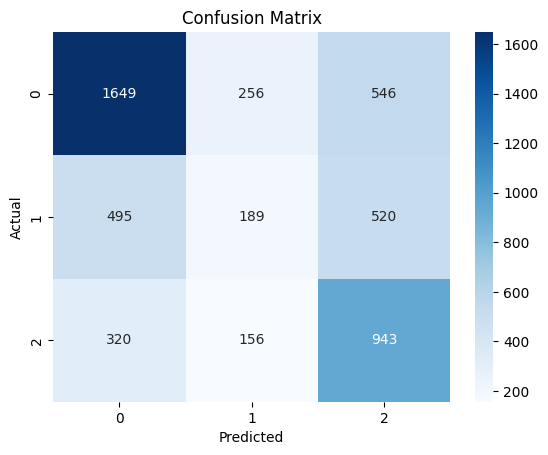

In [ ]:
model.eval()
with torch.no_grad():
    predictions = model(X_test_tensor).argmax(dim=1)
    acc = accuracy_score(y_test_tensor, predictions)
    print(f"Test Accuracy: {acc * 100:.2f}%")
    print("Classification Report:\n", classification_report(y_test_tensor, predictions))
    cm = confusion_matrix(y_test_tensor, predictions)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

### <font color='skyblue'>7. FIFA WORLD CUP 2022 Simulation</font>


In this part using another dataset we extract all group matches of WC 2022.

In [ ]:
wc2022 = pd.read_csv("Fifa_world_cup_matches.csv")
wcm = wc2022[wc2022['category'].str.match(r'^Group [A-H]$', na=False)][['team1', 'team2', 'category']]
wcm

,team1,team2,category
0,QATAR,ECUADOR,Group A
1,ENGLAND,IRAN,Group B
2,SENEGAL,NETHERLANDS,Group A
3,UNITED STATES,WALES,Group B
4,ARGENTINA,SAUDI ARABIA,Group C
5,DENMARK,TUNISIA,Group D
6,MEXICO,POLAND,Group C
7,FRANCE,AUSTRALIA,Group D
8,MOROCCO,CROATIA,Group F
9,GERMANY,JAPAN,Group E


We define a function to predict match by it's features using our trained model.

In [ ]:
def predict_match_result(model, scaler, y_encoder, match_features):
    model.eval()
    match_scaled = scaler.transform(match_features)
    tensor_input = torch.tensor(match_scaled, dtype=torch.float32)
    with torch.no_grad():
        pred = model(tensor_input).argmax(dim=1).numpy()
    return y_encoder.inverse_transform(pred)[0]

Here we define a function to predict all group matches and reach group phase tables.

In [ ]:
def simulate_group_stage(group_matches_df, full_dataset_df, model, scaler, y_encoder):
    group_tables = defaultdict(lambda: defaultdict(int))  # team -> points, goals, etc.

    for idx, row in group_matches_df.iterrows():
        team1, team2, group = row['team1'], row['team2'], row['category']

        # Try to find a real match in the historical dataset
        match_found = ((full_dataset_df['home_team'].str.upper() == team1.upper()) & (full_dataset_df['away_team'].str.upper() == team2.upper()))
        matched = full_dataset_df[match_found]

        if not matched.empty:
            # Take the first instance found and build feature vector
            feature_row = matched.iloc[0].drop(labels=['home_team', 'away_team', 'home_goals', 'away_goals', 'status', 'wcm', 'Unnamed: 0'])
            features = pd.DataFrame([feature_row])
            result = predict_match_result(model, scaler, y_encoder, features)
        else:
            # Simulate randomly
            print("*")
            result = random.choice(y_encoder.classes_)
        winner_name = ""
        # Update points based on result
        if result == 1:  # home win
            group_tables[group][team1] += 3
            group_tables[group][team2] += 0
            winner_name = team1 + " WON"
        elif result == 2:  # draw
            group_tables[group][team1] += 1
            group_tables[group][team2] += 1
            winner_name = "DRAW"
        elif result == 3:  # away win
            group_tables[group][team1] += 0
            group_tables[group][team2] += 3
            winner_name = team2 + " WON"

        print(f"{team1} vs {team2} ({group}) → Result: {winner_name}")

    return group_tables

We print group phase results and tables.

In [ ]:
group_results = simulate_group_stage(wcm, df, model, scaler, y_encoder)

for group, table in group_results.items():
    print(f"\n--- {group} Standings ---")
    sorted_teams = sorted(table.items(), key=lambda x: x[1], reverse=True)
    for team, pts in sorted_teams:
        print(f"{team}: {pts} pts")

QATAR vs ECUADOR (Group A) → Result: DRAW
*
ENGLAND vs IRAN (Group B) → Result: ENGLAND WON
*
SENEGAL vs NETHERLANDS (Group A) → Result: DRAW
UNITED STATES vs WALES (Group B) → Result: UNITED STATES WON
ARGENTINA vs SAUDI ARABIA (Group C) → Result: ARGENTINA WON
DENMARK vs TUNISIA (Group D) → Result: DRAW
MEXICO vs POLAND (Group C) → Result: MEXICO WON
FRANCE vs AUSTRALIA (Group D) → Result: FRANCE WON
MOROCCO vs CROATIA (Group F) → Result: DRAW
GERMANY vs JAPAN (Group E) → Result: DRAW
SPAIN vs COSTA RICA (Group E) → Result: SPAIN WON
*
BELGIUM vs CANADA (Group F) → Result: CANADA WON
*
SWITZERLAND vs CAMEROON (Group G) → Result: CAMEROON WON
*
URUGUAY vs KOREA REPUBLIC (Group H) → Result: KOREA REPUBLIC WON
PORTUGAL vs GHANA (Group H) → Result: DRAW
BRAZIL vs SERBIA (Group G) → Result: BRAZIL WON
*
WALES vs IRAN (Group B) → Result: DRAW
*
QATAR vs SENEGAL (Group A) → Result: QATAR WON
NETHERLANDS vs ECUADOR (Group A) → Result: NETHERLANDS WON
ENGLAND vs UNITED STATES (Group B) → Resu

This function resolve match winner similar to last part, with this difference that we don't have draw in knockout stage.

In [ ]:
def resolve_knockout_match(team1, team2, df, model, scaler, y_encoder):
    match_found = ((df['home_team'].str.upper() == team1.upper()) & (df['away_team'].str.upper() == team2.upper()))

    matched = df[match_found]

    if not matched.empty:
        feature_row = matched.iloc[0].drop(['home_team', 'away_team', 'home_goals', 'away_goals', 'status', 'wcm', 'Unnamed: 0'])
        features = pd.DataFrame([feature_row])
        result = predict_match_result(model, scaler, y_encoder, features)

        if result == 1:
            return team1
        elif result == 3:
            return team2
        else:  # Draw → Penalties
            return random.choice([team1, team2])
    else:
        print("*")
        return random.choice([team1, team2])

We defnie a function to simulate each round of knockput stage and print the results

In [ ]:
def play_round(matches):
    winners = []
    losers = []
    for team1, team2 in matches:
        winner = resolve_knockout_match(team1, team2, df, model, scaler, y_encoder)
        loser = team2 if winner == team1 else team1
        print(f"{team1} vs {team2} → Result: {winner} WON")
        winners.append(winner)
        losers.append(loser)
    return winners, losers

Finally we define tow functions, first for bringing group phase result and another for simulating knockout stage till Final.

In [ ]:
def get_group_winners(group_tables):
    group_winners = {}
    for group, teams in group_tables.items():
        sorted_teams = sorted(teams.items(), key=lambda x: x[1], reverse=True)
        group_winners[group] = [sorted_teams[0][0], sorted_teams[1][0]]  # top 2
    return group_winners

def simulate_knockout_stage(group_winners, df, model, scaler, y_encoder):
    # Setup Round of 16 matchups
    round_of_16 = [
        (group_winners['Group A'][0], group_winners['Group B'][1]),
        (group_winners['Group C'][0], group_winners['Group D'][1]),
        (group_winners['Group E'][0], group_winners['Group F'][1]),
        (group_winners['Group G'][0], group_winners['Group H'][1]),
        (group_winners['Group B'][0], group_winners['Group A'][1]),
        (group_winners['Group D'][0], group_winners['Group C'][1]),
        (group_winners['Group F'][0], group_winners['Group E'][1]),
        (group_winners['Group H'][0], group_winners['Group G'][1]),
    ]

    print("\n--- Round of 16 ---")
    qf_teams, _ = play_round(round_of_16)

    print("\n--- Quarterfinals ---")
    sf_teams, _ = play_round([(qf_teams[i], qf_teams[i + 1]) for i in range(0, 8, 2)])

    print("\n--- Semifinals ---")
    finalists, semifinal_losers = play_round([(sf_teams[i], sf_teams[i + 1]) for i in range(0, 4, 2)])

    print("\n--- Third Place Match ---")
    third_place_winner = play_round([(semifinal_losers[0], semifinal_losers[1])])[0][0]

    print("\n--- Final ---")
    champion = play_round([(finalists[0], finalists[1])])[0][0]

    print(f"\n🏆 World Champion: {champion}")
    return champion

In [ ]:
group_winners = get_group_winners(group_results)
simulate_knockout_stage(group_winners, df, model, scaler, y_encoder)


--- Round of 16 ---
NETHERLANDS vs IRAN → Result: NETHERLANDS WON
ARGENTINA vs DENMARK → Result: ARGENTINA WON
GERMANY vs BELGIUM → Result: GERMANY WON
CAMEROON vs GHANA → Result: CAMEROON WON
*
ENGLAND vs QATAR → Result: ENGLAND WON
FRANCE vs MEXICO → Result: FRANCE WON
CROATIA vs SPAIN → Result: SPAIN WON
*
KOREA REPUBLIC vs BRAZIL → Result: KOREA REPUBLIC WON

--- Quarterfinals ---
NETHERLANDS vs ARGENTINA → Result: ARGENTINA WON
GERMANY vs CAMEROON → Result: GERMANY WON
ENGLAND vs FRANCE → Result: ENGLAND WON
*
SPAIN vs KOREA REPUBLIC → Result: SPAIN WON

--- Semifinals ---
ARGENTINA vs GERMANY → Result: ARGENTINA WON
ENGLAND vs SPAIN → Result: ENGLAND WON

--- Third Place Match ---
GERMANY vs SPAIN → Result: GERMANY WON

--- Final ---
ARGENTINA vs ENGLAND → Result: ENGLAND WON

🏆 World Champion: ENGLAND


'ENGLAND'

##<font color='orange'>**Task 2: RNN**</font>

###<font color='skyblue'>Dataset Loading</font>

####1. Upload Dataset

In [3]:
!pip install -q kagglehub

import kagglehub
path = kagglehub.dataset_download("alsaniipe/flowers-multiclass-datasets")
print("✅ Dataset path:", path)

✅ Dataset path: /kaggle/input/flowers-multiclass-datasets


####2: Unzip and Load Dataset into Python

In [4]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

base_dir = "/kaggle/input/flowers-multiclass-datasets/flowers/flowers/flower_photos"

train_dir = f"{base_dir}/train"
val_dir   = f"{base_dir}/validation"
test_dir  = f"{base_dir}/test"

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.9, 1.0)),   # Crop up to 10%
    transforms.RandomHorizontalFlip(p=0.5),                # 50% flip chance
    transforms.RandomRotation(degrees=20),                 # ±20° rotation
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # Slight lighting changes
    transforms.ToTensor(),                                 # Converts to [0,1]
])

eval_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])


eval_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset   = datasets.ImageFolder(val_dir, transform=eval_transforms)
test_dataset  = datasets.ImageFolder(test_dir, transform=eval_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("✅ Classes:", train_dataset.classes)

✅ Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


The dataset has already been pre-divided into training, validation, and test sets, so there is no need for me to split it further.

###<font color='skyblue'>Image Preprocessing</font>

We have implemented Resize and Normalize steps so far.

####Labels

We used **torchvision.datasets.ImageFolder**, which handles label encoding automatically. However, we also implemented a separate data loader with one-hot encoding to allow experimentation with both encoding methods

#####1. Define one-hot wrapper

In [15]:
import torch
from torch.utils.data import Dataset

class OneHotDataset(Dataset):
    def __init__(self, base_dataset, num_classes):
        self.dataset = base_dataset
        self.num_classes = num_classes

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        one_hot_label = torch.zeros(self.num_classes)
        one_hot_label[label] = 1.0
        return image, one_hot_label

#####2. Create one-hot datasets and loaders

In [16]:
num_classes = len(train_dataset.classes)

train_dataset_oh = OneHotDataset(train_dataset, num_classes)
val_dataset_oh   = OneHotDataset(val_dataset, num_classes)
test_dataset_oh  = OneHotDataset(test_dataset, num_classes)

train_loader_oh = DataLoader(train_dataset_oh, batch_size=32, shuffle=True)
val_loader_oh   = DataLoader(val_dataset_oh, batch_size=32, shuffle=False)
test_loader_oh  = DataLoader(test_dataset_oh, batch_size=32, shuffle=False)

###<font color='skyblue'>Data Augmentation</font>

As shown in train_transforms, we have already implemented several data augmentation techniques, including random cropping, flipping, rotation, and color jittering, to enhance model generalization:

```
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.9, 1.0)),   # Crop up to 10%
    transforms.RandomHorizontalFlip(p=0.5),                # 50% flip chance
    transforms.RandomRotation(degrees=20),                 # ±20° rotation
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # Slight lighting changes
    transforms.ToTensor(),                                 # Converts to [0,1]
])
```

###<font color='skyblue'>Building a VGG CNN from Scratch</font>

####Label Encoding version

#####1. Define VGG-Style CNN

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class VGGStyleCNN(nn.Module):
    def __init__(self, num_classes):
        super(VGGStyleCNN, self).__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),  # output: 64x224x224
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),  # output: 64x224x224
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),        # output: 64x112x112

            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),        # output: 128x56x56

            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),        # output: 256x28x28
        )

        self.classifier = nn.Sequential(
            nn.Linear(256 * 28 * 28, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.classifier(x)
        return x


#####2. Training & Evaluation Loops

In [18]:
import torch.optim as optim

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = len(train_dataset.classes)
model = VGGStyleCNN(num_classes).to(device)

criterion = nn.CrossEntropyLoss()

#####3. Training Function

In [19]:
def train(model, dataloader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    avg_loss = running_loss / total
    accuracy = 100 * correct / total
    return avg_loss, accuracy


#####4. Validation Function

In [20]:
def evaluate(model, dataloader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_loss = running_loss / total
    accuracy = 100 * correct / total
    return avg_loss, accuracy


#####5. Training Loop Execution

In [21]:
from torch.optim.lr_scheduler import ReduceLROnPlateau
import numpy as np

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Reduce LR if val loss doesn't improve for 3 epochs (factor = 0.1)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3, verbose=True)

# Early stopping params
early_stop_patience = 5
best_val_loss = np.inf
early_stop_counter = 0


In [22]:
label_train_loss_history = []
label_val_loss_history = []
label_train_acc_history = []
label_val_acc_history = []

num_epochs = 30
best_val_loss = float('inf')
patience = 5
counter = 0

# Scheduler: Decays LR by 0.1 every 10 epochs
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

for epoch in range(num_epochs):
    train_loss, train_acc = train(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    label_train_loss_history.append(train_loss)
    label_val_loss_history.append(val_loss)
    label_train_acc_history.append(train_acc)
    label_val_acc_history.append(val_acc)

    print(f"[Epoch {epoch+1:02d}] Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}% | Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    # Early Stopping Check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        best_model_state = model.state_dict()  # Save best model
    else:
        counter += 1
        if counter >= patience:
            print(f"⚠️ Early stopping triggered at epoch {epoch+1}")
            break

    # Step learning rate scheduler
    scheduler.step()

# Restore best model
model.load_state_dict(best_model_state)
print("✅ Best model restored from epoch with lowest validation loss.")


[Epoch 01] Train Acc: 26.27%, Val Acc: 41.25% | Train Loss: 1.5887, Val Loss: 1.4803
[Epoch 02] Train Acc: 43.64%, Val Acc: 53.75% | Train Loss: 1.3072, Val Loss: 1.0749
[Epoch 03] Train Acc: 51.02%, Val Acc: 62.50% | Train Loss: 1.1650, Val Loss: 0.8713
[Epoch 04] Train Acc: 56.81%, Val Acc: 62.50% | Train Loss: 1.0730, Val Loss: 0.8941
[Epoch 05] Train Acc: 60.65%, Val Acc: 71.25% | Train Loss: 1.0199, Val Loss: 0.8254
[Epoch 06] Train Acc: 62.66%, Val Acc: 75.00% | Train Loss: 0.9621, Val Loss: 0.7385
[Epoch 07] Train Acc: 66.44%, Val Acc: 71.25% | Train Loss: 0.8899, Val Loss: 0.8121
[Epoch 08] Train Acc: 67.57%, Val Acc: 70.00% | Train Loss: 0.8565, Val Loss: 0.7300
[Epoch 09] Train Acc: 69.32%, Val Acc: 75.00% | Train Loss: 0.8295, Val Loss: 0.6732
[Epoch 10] Train Acc: 70.34%, Val Acc: 68.75% | Train Loss: 0.7802, Val Loss: 0.7672
[Epoch 11] Train Acc: 73.50%, Val Acc: 77.50% | Train Loss: 0.7072, Val Loss: 0.6376
[Epoch 12] Train Acc: 73.73%, Val Acc: 77.50% | Train Loss: 0.688

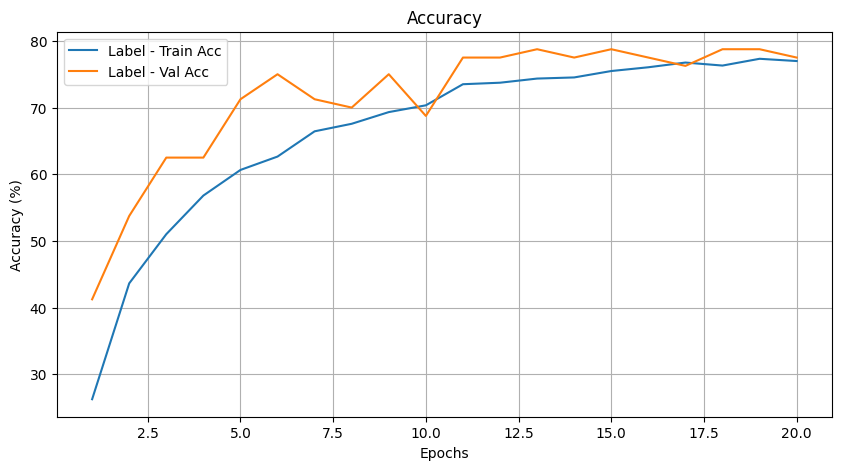

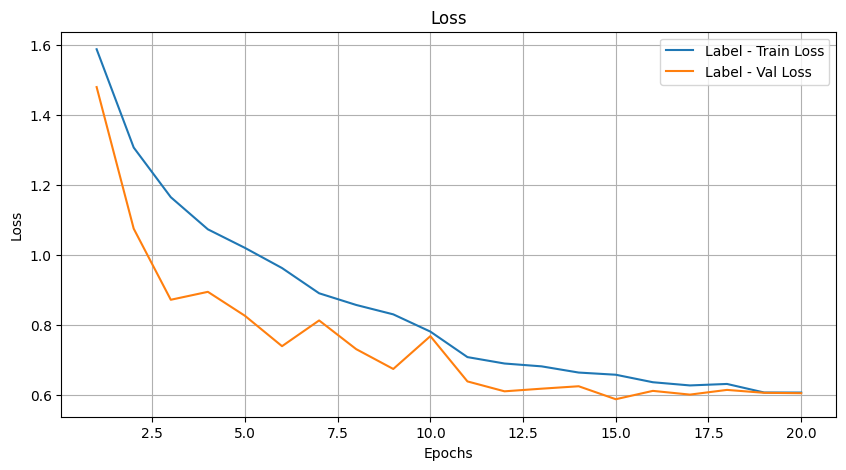

In [23]:
import matplotlib.pyplot as plt

epochs = range(1, len(label_train_acc_history) + 1)

# Accuracy
plt.figure(figsize=(10, 5))
plt.plot(epochs, label_train_acc_history, label='Label - Train Acc')
plt.plot(epochs, label_val_acc_history, label='Label - Val Acc')
plt.title("Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(10, 5))
plt.plot(epochs, label_train_loss_history, label='Label - Train Loss')
plt.plot(epochs, label_val_loss_history, label='Label - Val Loss')
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


#####6. Evaluate Model Metrics

In [24]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score, roc_curve
)
import seaborn as sns
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np

def evaluate_model_metrics(model, dataloader, is_onehot=False):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            if is_onehot:
                probs = torch.sigmoid(outputs)
                preds = torch.argmax(probs, dim=1)
                all_probs.append(probs.cpu())
                labels = torch.argmax(labels, dim=1)
            else:
                probs = F.softmax(outputs, dim=1)
                preds = torch.argmax(probs, dim=1)
                all_probs.append(probs.cpu())

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    y_score = torch.cat(all_probs).numpy()

    # Accuracy metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro')
    rec = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')
    cm = confusion_matrix(y_true, y_pred)

    print(f"✅ Accuracy:  {acc:.4f}")
    print(f"✅ Precision: {prec:.4f}")
    print(f"✅ Recall:    {rec:.4f}")
    print(f"✅ F1-Score:  {f1:.4f}")

    print("\n")

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    print("\n")

    # ROC & AUC
    num_classes = y_score.shape[1]
    y_true_onehot = F.one_hot(torch.tensor(y_true), num_classes=num_classes).numpy()
    auc_score = roc_auc_score(y_true_onehot, y_score, multi_class='ovr')
    print(f"✅ AUC Score (OVR): {auc_score:.4f}")

    print("\n")

    # Plot ROC curve for each class
    plt.figure(figsize=(10, 8))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_true_onehot[:, i], y_score[:, i])
        plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc_score(y_true_onehot[:, i], y_score[:, i]):.2f})")

    plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
    plt.title("ROC Curves per Class")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

✅ Accuracy:  0.6800
✅ Precision: 0.6752
✅ Recall:    0.6800
✅ F1-Score:  0.6589




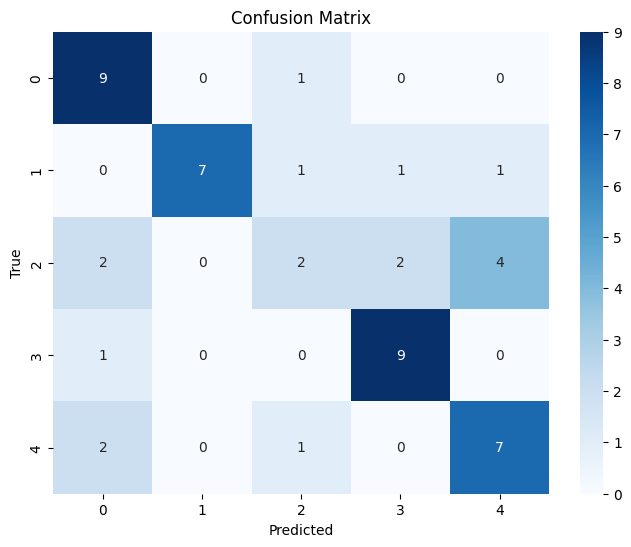



✅ AUC Score (OVR): 0.9125




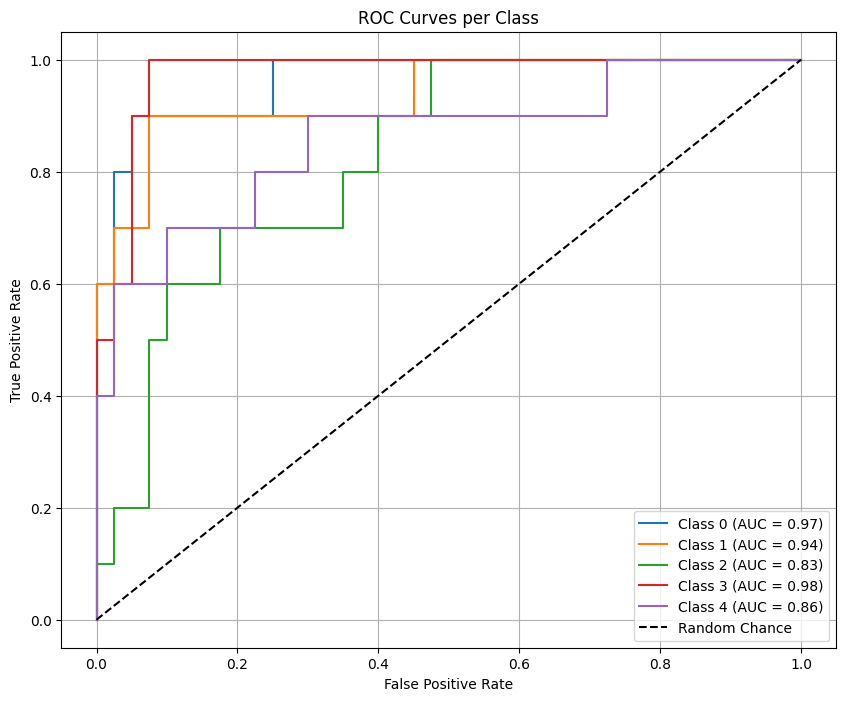

In [25]:
evaluate_model_metrics(model, test_loader, is_onehot=False)

####One-hot Encoding version

#####1. Define VGG-Style CNN

In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class VGGStyleCNN(nn.Module):
    def __init__(self, num_classes):
        super(VGGStyleCNN, self).__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),  # output: 64x224x224
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),  # output: 64x224x224
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),        # output: 64x112x112

            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),        # output: 128x56x56

            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),        # output: 256x28x28
        )

        self.classifier = nn.Sequential(
            nn.Linear(256 * 28 * 28, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.classifier(x)
        return x


#####2. Training & Evaluation Loops

In [27]:
from torch.nn import BCEWithLogitsLoss

model = VGGStyleCNN(num_classes).to(device)  # reinitialize model
criterion = BCEWithLogitsLoss()

#####3. Training Function

In [28]:
def train_onehot(model, dataloader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        predicted = torch.argmax(outputs, dim=1)
        true = torch.argmax(labels, dim=1)
        total += labels.size(0)
        correct += (predicted == true).sum().item()

    return running_loss / total, 100 * correct / total


#####4. Validation Function

In [29]:
def evaluate_onehot(model, dataloader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            predicted = torch.argmax(outputs, dim=1)
            true = torch.argmax(labels, dim=1)
            total += labels.size(0)
            correct += (predicted == true).sum().item()

    return running_loss / total, 100 * correct / total

#####5. Training Loop Execution

In [30]:
from torch.optim.lr_scheduler import ReduceLROnPlateau
import numpy as np

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Reduce LR if val loss doesn't improve for 3 epochs (factor = 0.1)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3, verbose=True)

# Early stopping params
early_stop_patience = 5
best_val_loss = np.inf
early_stop_counter = 0

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [31]:
onehot_train_loss_history = []
onehot_val_loss_history = []
onehot_train_acc_history = []
onehot_val_acc_history = []

num_epochs = 30
best_val_loss = float('inf')
patience = 5
counter = 0

# Scheduler: Decays LR by 0.1 every 10 epochs
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

for epoch in range(num_epochs):
    train_loss, train_acc = train_onehot(model, train_loader_oh, optimizer, criterion)
    val_loss, val_acc = evaluate_onehot(model, val_loader_oh, criterion)

    onehot_train_loss_history.append(train_loss)
    onehot_val_loss_history.append(val_loss)
    onehot_train_acc_history.append(train_acc)
    onehot_val_acc_history.append(val_acc)

    print(f"[One-Hot Epoch {epoch+1:02d}] Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}% | Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        best_model_state = model.state_dict()  # Save best weights
    else:
        counter += 1
        if counter >= patience:
            print(f"⚠️ Early stopping triggered at epoch {epoch+1}")
            break

    scheduler.step()

# Restore best model
model.load_state_dict(best_model_state)
print("✅ Best model (one-hot) restored from epoch with lowest validation loss.")


[One-Hot Epoch 01] Train Acc: 23.14%, Val Acc: 33.75% | Train Loss: 0.5075, Val Loss: 0.4579
[One-Hot Epoch 02] Train Acc: 38.42%, Val Acc: 31.25% | Train Loss: 0.4464, Val Loss: 0.4498
[One-Hot Epoch 03] Train Acc: 41.58%, Val Acc: 38.75% | Train Loss: 0.4323, Val Loss: 0.4154
[One-Hot Epoch 04] Train Acc: 44.24%, Val Acc: 46.25% | Train Loss: 0.4192, Val Loss: 0.4052
[One-Hot Epoch 05] Train Acc: 46.95%, Val Acc: 52.50% | Train Loss: 0.4126, Val Loss: 0.3888
[One-Hot Epoch 06] Train Acc: 49.60%, Val Acc: 55.00% | Train Loss: 0.4073, Val Loss: 0.3750
[One-Hot Epoch 07] Train Acc: 53.39%, Val Acc: 60.00% | Train Loss: 0.3862, Val Loss: 0.3339
[One-Hot Epoch 08] Train Acc: 54.92%, Val Acc: 60.00% | Train Loss: 0.3704, Val Loss: 0.3519
[One-Hot Epoch 09] Train Acc: 56.58%, Val Acc: 60.00% | Train Loss: 0.3576, Val Loss: 0.3038
[One-Hot Epoch 10] Train Acc: 58.62%, Val Acc: 63.75% | Train Loss: 0.3447, Val Loss: 0.2965
[One-Hot Epoch 11] Train Acc: 62.26%, Val Acc: 62.50% | Train Loss: 0.

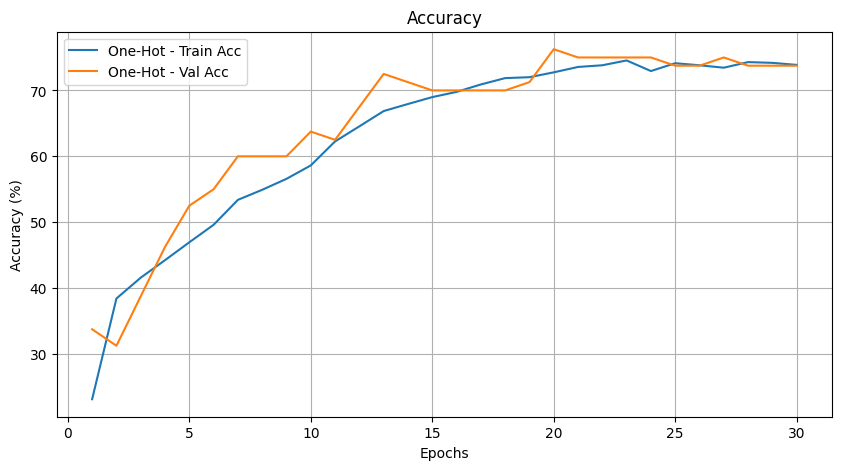

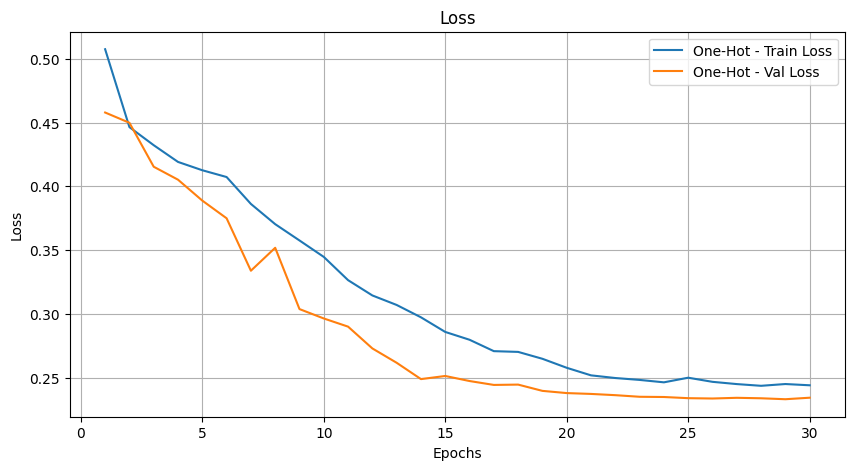

In [32]:
import matplotlib.pyplot as plt

epochs = range(1, len(onehot_train_loss_history) + 1)

# Accuracy
plt.figure(figsize=(10, 5))
plt.plot(epochs, onehot_train_acc_history, label='One-Hot - Train Acc')
plt.plot(epochs, onehot_val_acc_history, label='One-Hot - Val Acc')
plt.title("Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(10, 5))
plt.plot(epochs, onehot_train_loss_history, label='One-Hot - Train Loss')
plt.plot(epochs, onehot_val_loss_history, label='One-Hot - Val Loss')
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


#####6. Evaluate Model Metrics

✅ Accuracy:  0.6000
✅ Precision: 0.5710
✅ Recall:    0.6000
✅ F1-Score:  0.5689




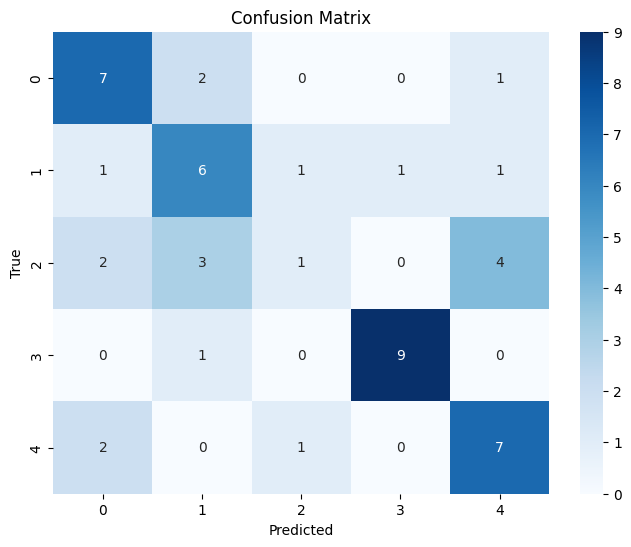



✅ AUC Score (OVR): 0.8625




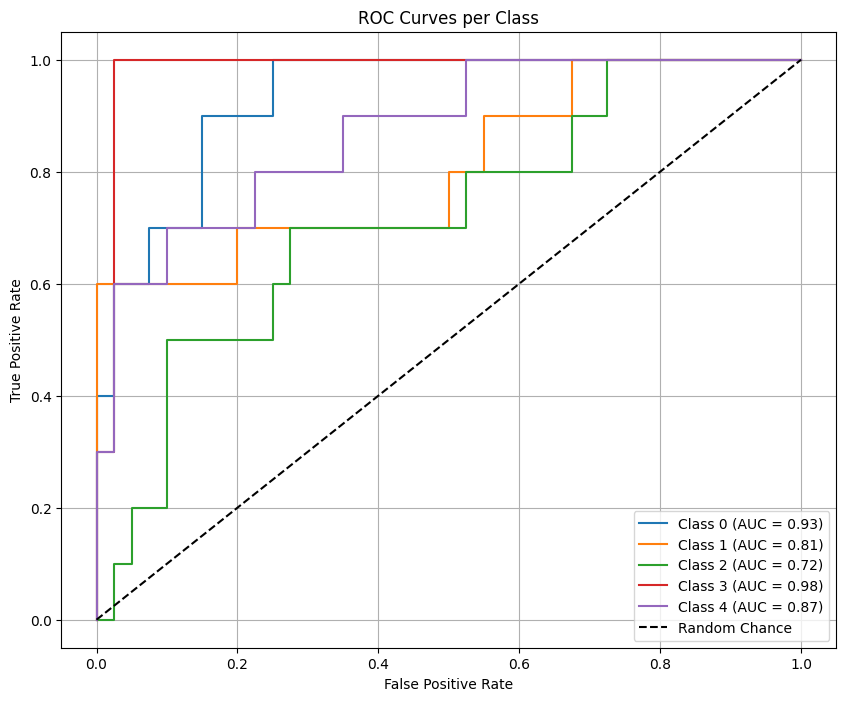

In [33]:
evaluate_model_metrics(model, test_loader_oh, is_onehot=True)

###<font color='skyblue'>**Fine-Tuning a Pretrained ResNet**</font>

####Label Encoding version

#####1: ResNet Loader per Stage

In [34]:
from torchvision import models
import torch.nn as nn

def get_resnet50_model(num_classes=5, stage="head_only"):
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

    # Freeze layers depending on stage
    if stage == "head_only":
        for param in model.parameters():
            param.requires_grad = False
    elif stage == "layer4":
        for name, param in model.named_parameters():
            if "layer4" not in name and "fc" not in name:
                param.requires_grad = False
    elif stage == "all":
        for param in model.parameters():
            param.requires_grad = True

    # Replace classifier
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


#####2: Loss & Optimizer

In [35]:
criterion_label = nn.CrossEntropyLoss()

def get_optimizer(model, lr=1e-3):
    return torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

#####3: Training Loop per Stage

In [36]:
def train_resnet(model, train_loader, val_loader, criterion, optimizer,
                 num_epochs=10,
                 train_acc_hist=None, val_acc_hist=None,
                 train_loss_hist=None, val_loss_hist=None,
                 patience=5):

    model.to(device)
    best_val_loss = float('inf')
    best_model_state = None
    stop_counter = 0

    for epoch in range(num_epochs):
        model.train()
        total, correct, train_loss = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1) if criterion == criterion_label else torch.argmax(torch.sigmoid(outputs), dim=1)
            targets = labels if criterion == criterion_label else torch.argmax(labels, dim=1)
            correct += (preds == targets).sum().item()
            total += images.size(0)

        train_acc = 100 * correct / total
        train_loss /= total

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1) if criterion == criterion_label else torch.argmax(torch.sigmoid(outputs), dim=1)
                targets = labels if criterion == criterion_label else torch.argmax(labels, dim=1)
                val_correct += (preds == targets).sum().item()
                val_total += images.size(0)

        val_acc = 100 * val_correct / val_total
        val_loss /= val_total

        print(f"[{epoch+1:02d}] Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        # Save history
        if train_acc_hist is not None: train_acc_hist.append(train_acc)
        if val_acc_hist is not None: val_acc_hist.append(val_acc)
        if train_loss_hist is not None: train_loss_hist.append(train_loss)
        if val_loss_hist is not None: val_loss_hist.append(val_loss)

        # Early stopping logic
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict()
            stop_counter = 0
        else:
            stop_counter += 1
            if stop_counter >= patience:
                print(f"⏹️ Early stopping triggered at epoch {epoch+1}")
                break

    # Restore best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print("✅ Best model restored from epoch with lowest validation loss.")


#####4: Run Per Stage

######Freeze Base, Train Head

In [37]:
label_train_acc_history = []
label_val_acc_history = []
label_train_loss_history = []
label_val_loss_history = []


model = get_resnet50_model(stage="head_only")
optimizer = get_optimizer(model)
train_resnet(model, train_loader, val_loader, criterion_label, optimizer,
             num_epochs=10,
             train_acc_hist=label_train_acc_history,
             val_acc_hist=label_val_acc_history,
             train_loss_hist=label_train_loss_history,
             val_loss_hist=label_val_loss_history,
             patience=5)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 197MB/s]


[01] Train Acc: 76.89% | Val Acc: 87.50% | Train Loss: 0.8073 | Val Loss: 0.5130
[02] Train Acc: 87.37% | Val Acc: 86.25% | Train Loss: 0.4322 | Val Loss: 0.4342
[03] Train Acc: 90.20% | Val Acc: 88.75% | Train Loss: 0.3405 | Val Loss: 0.3731
[04] Train Acc: 91.36% | Val Acc: 88.75% | Train Loss: 0.2964 | Val Loss: 0.3203
[05] Train Acc: 92.34% | Val Acc: 88.75% | Train Loss: 0.2644 | Val Loss: 0.3168
[06] Train Acc: 92.88% | Val Acc: 90.00% | Train Loss: 0.2388 | Val Loss: 0.3130
[07] Train Acc: 93.50% | Val Acc: 92.50% | Train Loss: 0.2232 | Val Loss: 0.3032
[08] Train Acc: 93.50% | Val Acc: 90.00% | Train Loss: 0.2079 | Val Loss: 0.2839
[09] Train Acc: 94.46% | Val Acc: 88.75% | Train Loss: 0.1953 | Val Loss: 0.2933
[10] Train Acc: 94.46% | Val Acc: 91.25% | Train Loss: 0.1855 | Val Loss: 0.2764
✅ Best model restored from epoch with lowest validation loss.


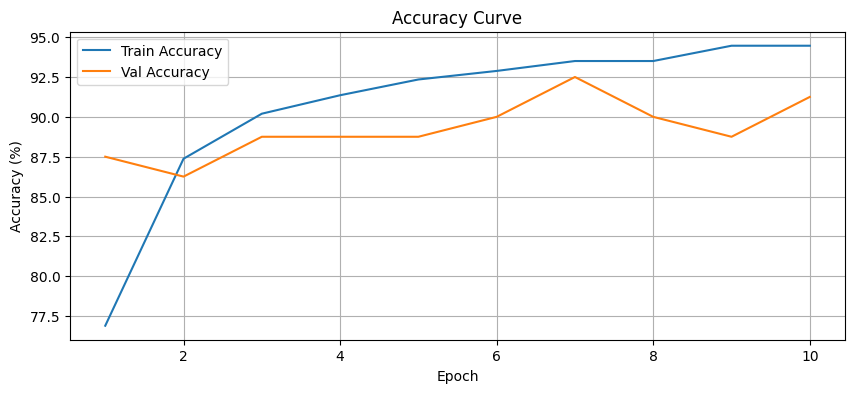

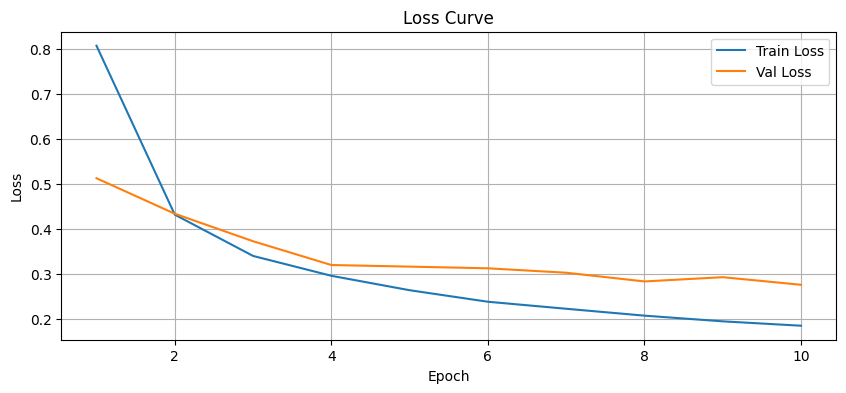

In [38]:
import matplotlib.pyplot as plt

epochs = range(1, len(label_train_acc_history) + 1)

plt.figure(figsize=(10, 4))
plt.plot(epochs, label_train_acc_history, label="Train Accuracy")
plt.plot(epochs, label_val_acc_history, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(epochs, label_train_loss_history, label="Train Loss")
plt.plot(epochs, label_val_loss_history, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid(True)
plt.show()


✅ Accuracy:  0.9125
✅ Precision: 0.9123
✅ Recall:    0.9125
✅ F1-Score:  0.9121




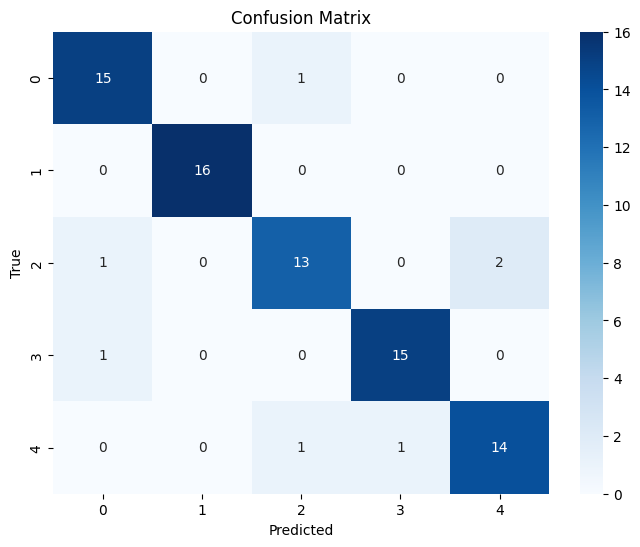



✅ AUC Score (OVR): 0.9906




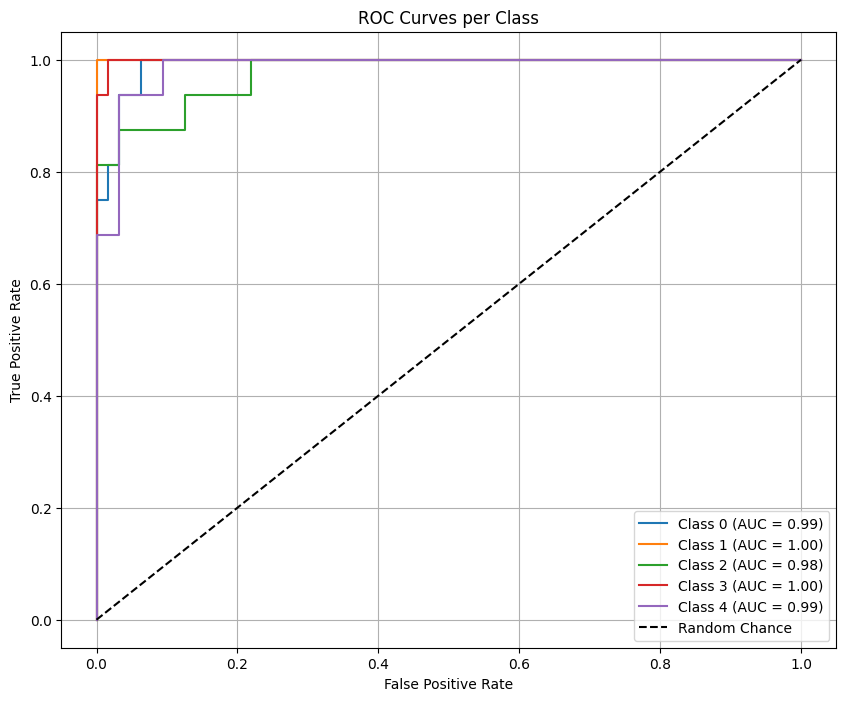

In [39]:
evaluate_model_metrics(model, val_loader, is_onehot=False)

######Unfreeze Last Conv Layer

In [40]:
label_train_acc_history = []
label_val_acc_history = []
label_train_loss_history = []
label_val_loss_history = []


model = get_resnet50_model(stage="layer4")
optimizer = get_optimizer(model, lr=1e-4)
train_resnet(model, train_loader, val_loader, criterion_label, optimizer,
             num_epochs=10,
             train_acc_hist=label_train_acc_history,
             val_acc_hist=label_val_acc_history,
             train_loss_hist=label_train_loss_history,
             val_loss_hist=label_val_loss_history,
             patience=5)

[01] Train Acc: 81.78% | Val Acc: 91.25% | Train Loss: 0.6244 | Val Loss: 0.2773
[02] Train Acc: 93.42% | Val Acc: 91.25% | Train Loss: 0.2019 | Val Loss: 0.2085
[03] Train Acc: 95.68% | Val Acc: 95.00% | Train Loss: 0.1353 | Val Loss: 0.2627
[04] Train Acc: 97.77% | Val Acc: 93.75% | Train Loss: 0.0783 | Val Loss: 0.2745
[05] Train Acc: 98.19% | Val Acc: 92.50% | Train Loss: 0.0630 | Val Loss: 0.1934
[06] Train Acc: 98.47% | Val Acc: 91.25% | Train Loss: 0.0506 | Val Loss: 0.1994
[07] Train Acc: 98.70% | Val Acc: 92.50% | Train Loss: 0.0440 | Val Loss: 0.1983
[08] Train Acc: 99.12% | Val Acc: 92.50% | Train Loss: 0.0283 | Val Loss: 0.2001
[09] Train Acc: 99.18% | Val Acc: 91.25% | Train Loss: 0.0236 | Val Loss: 0.2720
[10] Train Acc: 99.24% | Val Acc: 95.00% | Train Loss: 0.0323 | Val Loss: 0.2565
⏹️ Early stopping triggered at epoch 10
✅ Best model restored from epoch with lowest validation loss.


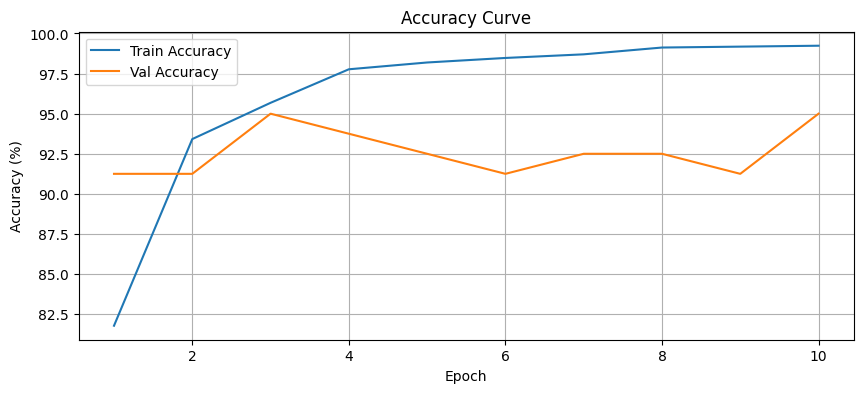

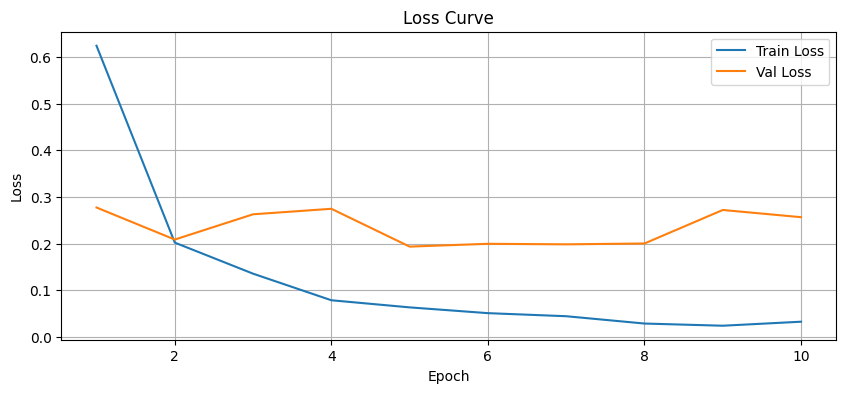

In [41]:
import matplotlib.pyplot as plt

epochs = range(1, len(label_train_acc_history) + 1)

plt.figure(figsize=(10, 4))
plt.plot(epochs, label_train_acc_history, label="Train Accuracy")
plt.plot(epochs, label_val_acc_history, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(epochs, label_train_loss_history, label="Train Loss")
plt.plot(epochs, label_val_loss_history, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid(True)
plt.show()


✅ Accuracy:  0.9500
✅ Precision: 0.9510
✅ Recall:    0.9500
✅ F1-Score:  0.9491




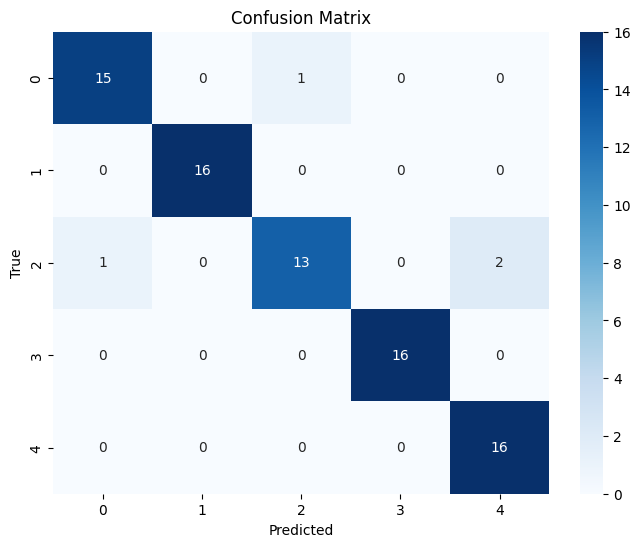



✅ AUC Score (OVR): 0.9902




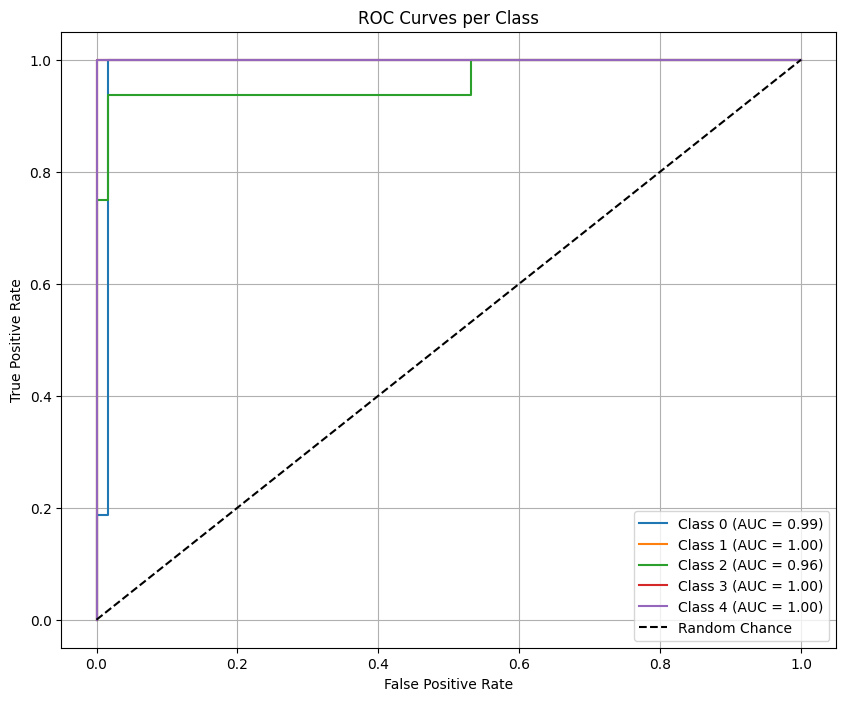

In [42]:
evaluate_model_metrics(model, val_loader, is_onehot=False)

######Unfreeze All

In [43]:
label_train_acc_history = []
label_val_acc_history = []
label_train_loss_history = []
label_val_loss_history = []


model = get_resnet50_model(stage="all")
optimizer = get_optimizer(model, lr=1e-5)
train_resnet(model, train_loader, val_loader, criterion_label, optimizer,
             num_epochs=10,
             train_acc_hist=label_train_acc_history,
             val_acc_hist=label_val_acc_history,
             train_loss_hist=label_train_loss_history,
             val_loss_hist=label_val_loss_history,
             patience=5)

[01] Train Acc: 48.28% | Val Acc: 73.75% | Train Loss: 1.4681 | Val Loss: 1.2162
[02] Train Acc: 79.69% | Val Acc: 85.00% | Train Loss: 0.9927 | Val Loss: 0.6424
[03] Train Acc: 87.18% | Val Acc: 87.50% | Train Loss: 0.5817 | Val Loss: 0.4166
[04] Train Acc: 88.98% | Val Acc: 90.00% | Train Loss: 0.3939 | Val Loss: 0.3336
[05] Train Acc: 91.07% | Val Acc: 91.25% | Train Loss: 0.2998 | Val Loss: 0.3103
[06] Train Acc: 91.84% | Val Acc: 91.25% | Train Loss: 0.2553 | Val Loss: 0.2703
[07] Train Acc: 94.04% | Val Acc: 91.25% | Train Loss: 0.2055 | Val Loss: 0.2624
[08] Train Acc: 94.60% | Val Acc: 91.25% | Train Loss: 0.1766 | Val Loss: 0.2436
[09] Train Acc: 94.92% | Val Acc: 91.25% | Train Loss: 0.1578 | Val Loss: 0.2331
[10] Train Acc: 95.56% | Val Acc: 92.50% | Train Loss: 0.1418 | Val Loss: 0.2090
✅ Best model restored from epoch with lowest validation loss.


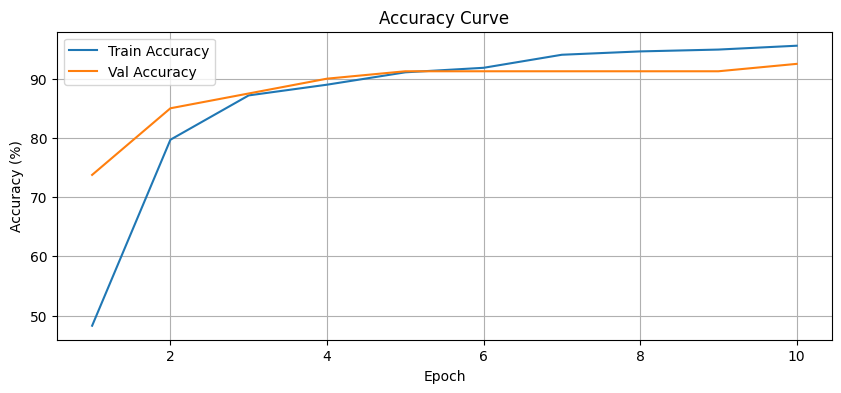

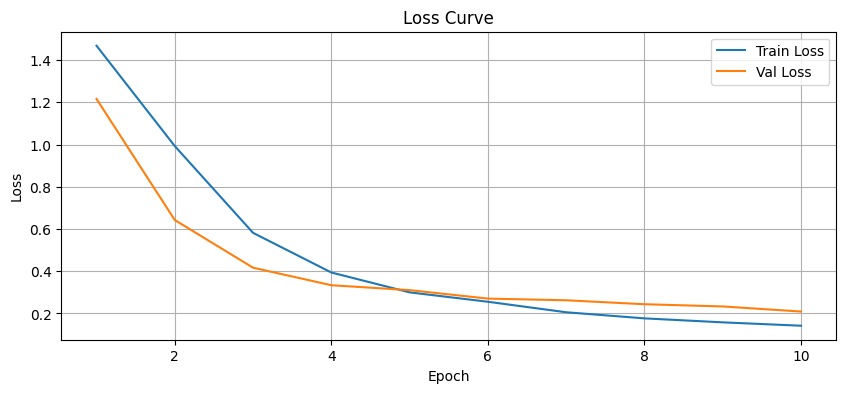

In [44]:
import matplotlib.pyplot as plt

epochs = range(1, len(label_train_acc_history) + 1)

plt.figure(figsize=(10, 4))
plt.plot(epochs, label_train_acc_history, label="Train Accuracy")
plt.plot(epochs, label_val_acc_history, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(epochs, label_train_loss_history, label="Train Loss")
plt.plot(epochs, label_val_loss_history, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid(True)
plt.show()


✅ Accuracy:  0.9250
✅ Precision: 0.9258
✅ Recall:    0.9250
✅ F1-Score:  0.9231




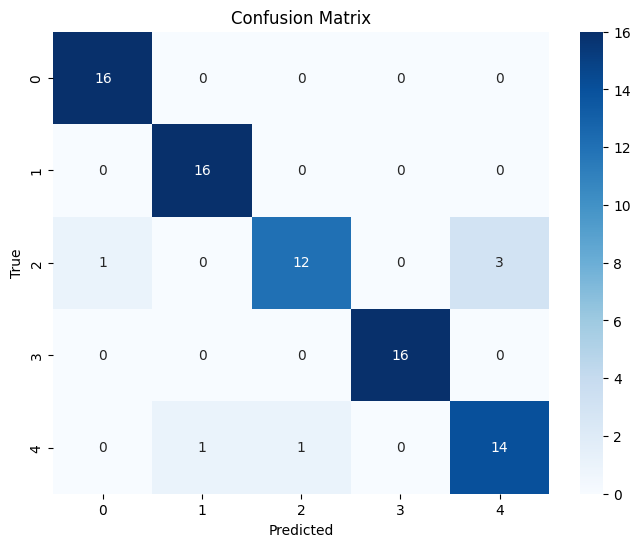



✅ AUC Score (OVR): 0.9936




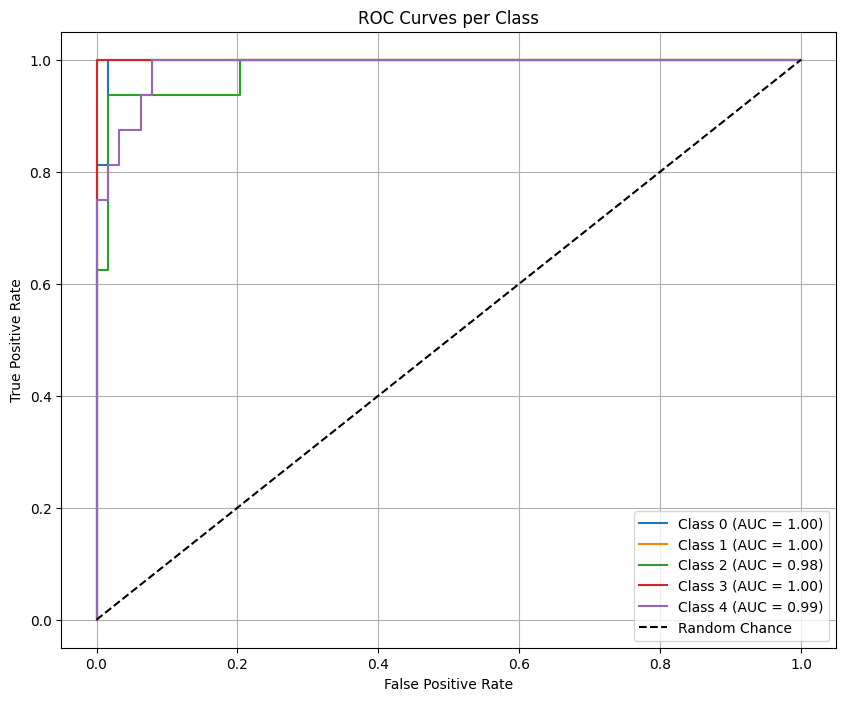

In [45]:
evaluate_model_metrics(model, val_loader, is_onehot=False)

####One-hot Encoding version

#####1: ResNet Loader per Stage

In [46]:
from torchvision import models
import torch.nn as nn

def get_resnet50_model(num_classes=5, stage="head_only"):
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

    # Freeze layers depending on stage
    if stage == "head_only":
        for param in model.parameters():
            param.requires_grad = False
    elif stage == "layer4":
        for name, param in model.named_parameters():
            if "layer4" not in name and "fc" not in name:
                param.requires_grad = False
    elif stage == "all":
        for param in model.parameters():
            param.requires_grad = True

    # Replace classifier
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


#####2: Loss & Optimizer

In [47]:
criterion_onehot = nn.BCEWithLogitsLoss()

def get_optimizer(model, lr=1e-3):
    return torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

#####3: Training Loop per Stage

In [48]:
def train_resnet(model, train_loader, val_loader, criterion, optimizer,
                 num_epochs=10,
                 train_acc_hist=None, val_acc_hist=None,
                 train_loss_hist=None, val_loss_hist=None,
                 patience=5):

    model.to(device)
    best_val_loss = float('inf')
    best_model_state = None
    stop_counter = 0

    for epoch in range(num_epochs):
        model.train()
        total, correct, train_loss = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1) if criterion == criterion_label else torch.argmax(torch.sigmoid(outputs), dim=1)
            targets = labels if criterion == criterion_label else torch.argmax(labels, dim=1)
            correct += (preds == targets).sum().item()
            total += images.size(0)

        train_acc = 100 * correct / total
        train_loss /= total

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1) if criterion == criterion_label else torch.argmax(torch.sigmoid(outputs), dim=1)
                targets = labels if criterion == criterion_label else torch.argmax(labels, dim=1)
                val_correct += (preds == targets).sum().item()
                val_total += images.size(0)

        val_acc = 100 * val_correct / val_total
        val_loss /= val_total

        print(f"[{epoch+1:02d}] Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        # Save history
        if train_acc_hist is not None: train_acc_hist.append(train_acc)
        if val_acc_hist is not None: val_acc_hist.append(val_acc)
        if train_loss_hist is not None: train_loss_hist.append(train_loss)
        if val_loss_hist is not None: val_loss_hist.append(val_loss)

        # Early stopping logic
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict()
            stop_counter = 0
        else:
            stop_counter += 1
            if stop_counter >= patience:
                print(f"⏹️ Early stopping triggered at epoch {epoch+1}")
                break

    # Restore best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print("✅ Best model restored from epoch with lowest validation loss.")


#####4: Run Per Stage

######Freeze Base, Train Head

In [49]:
onehot_train_acc_history = []
onehot_val_acc_history = []
onehot_train_loss_history = []
onehot_val_loss_history = []


model = get_resnet50_model(stage="head_only")
optimizer = get_optimizer(model)
train_resnet(model, train_loader_oh, val_loader_oh, criterion_onehot, optimizer,
             num_epochs=10,
             train_acc_hist=onehot_train_acc_history,
             val_acc_hist=onehot_val_acc_history,
             train_loss_hist=onehot_train_loss_history,
             val_loss_hist=onehot_val_loss_history,
             patience=5)

[01] Train Acc: 72.99% | Val Acc: 76.25% | Train Loss: 0.3423 | Val Loss: 0.2535
[02] Train Acc: 85.90% | Val Acc: 83.75% | Train Loss: 0.2048 | Val Loss: 0.1895
[03] Train Acc: 88.95% | Val Acc: 86.25% | Train Loss: 0.1641 | Val Loss: 0.1721
[04] Train Acc: 89.72% | Val Acc: 87.50% | Train Loss: 0.1455 | Val Loss: 0.1474
[05] Train Acc: 90.73% | Val Acc: 86.25% | Train Loss: 0.1310 | Val Loss: 0.1412
[06] Train Acc: 92.03% | Val Acc: 88.75% | Train Loss: 0.1208 | Val Loss: 0.1336
[07] Train Acc: 92.03% | Val Acc: 87.50% | Train Loss: 0.1171 | Val Loss: 0.1300
[08] Train Acc: 92.63% | Val Acc: 88.75% | Train Loss: 0.1080 | Val Loss: 0.1230
[09] Train Acc: 93.08% | Val Acc: 85.00% | Train Loss: 0.1022 | Val Loss: 0.1281
[10] Train Acc: 93.39% | Val Acc: 87.50% | Train Loss: 0.0983 | Val Loss: 0.1227
✅ Best model restored from epoch with lowest validation loss.


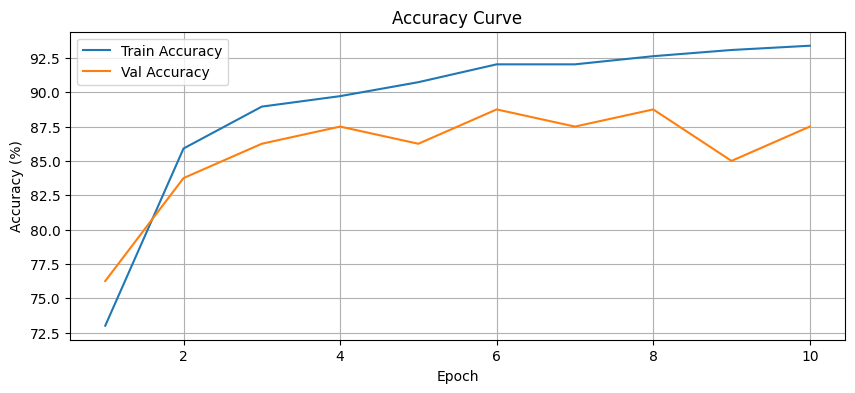

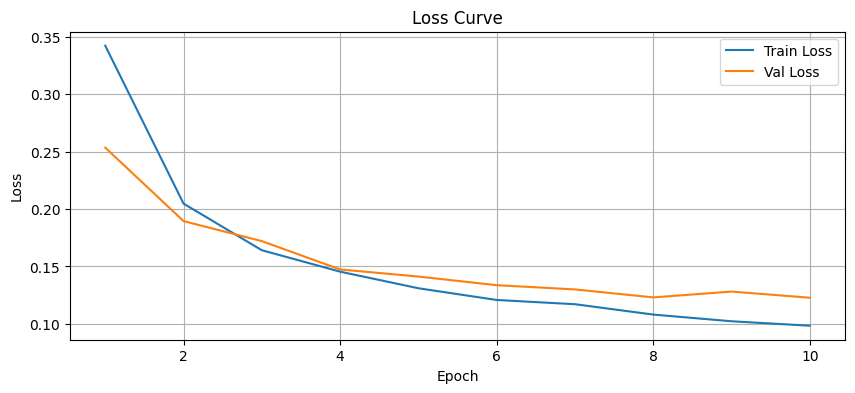

In [50]:
import matplotlib.pyplot as plt

epochs = range(1, len(onehot_train_acc_history) + 1)

plt.figure(figsize=(10, 4))
plt.plot(epochs, onehot_train_acc_history, label="Train Accuracy")
plt.plot(epochs, onehot_val_acc_history, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(epochs, onehot_train_loss_history, label="Train Loss")
plt.plot(epochs, onehot_val_loss_history, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid(True)
plt.show()


✅ Accuracy:  0.8750
✅ Precision: 0.8806
✅ Recall:    0.8750
✅ F1-Score:  0.8733




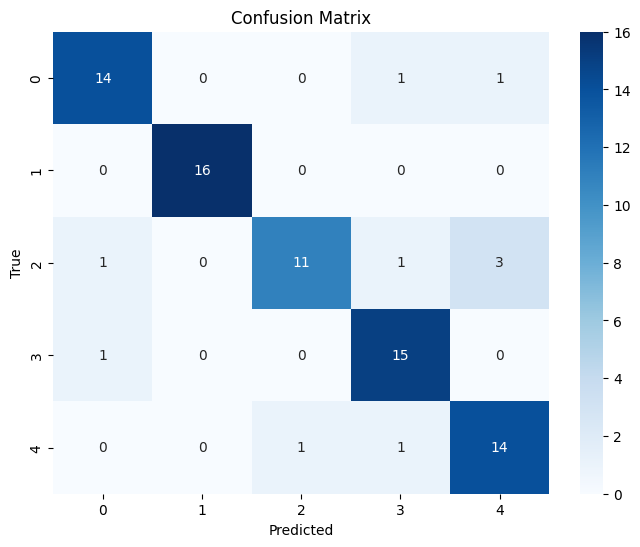



✅ AUC Score (OVR): 0.9816




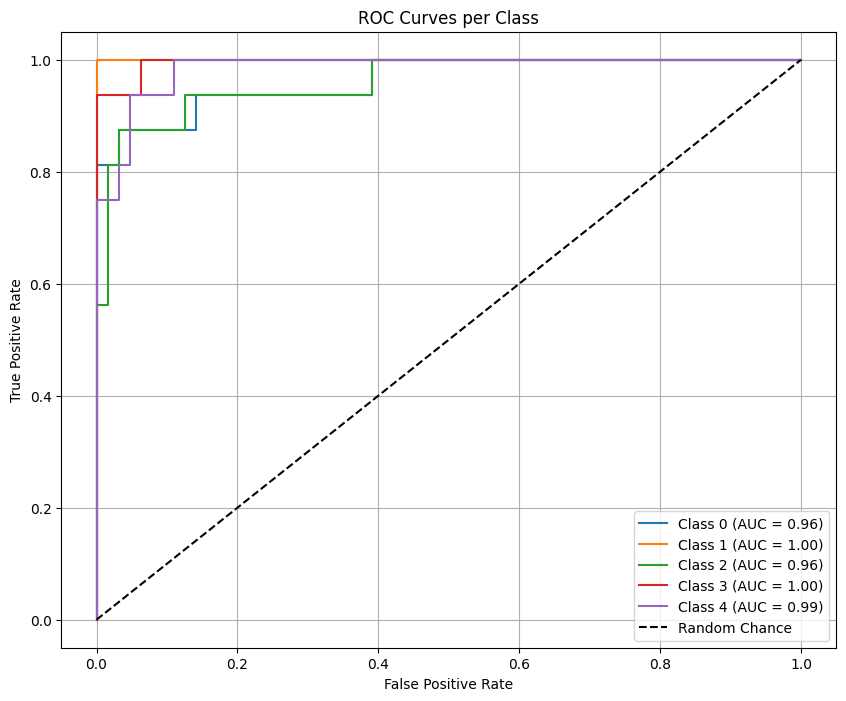

In [51]:
evaluate_model_metrics(model, val_loader_oh, is_onehot=True)

######Unfreeze Last Conv Layer

In [52]:
onehot_train_acc_history = []
onehot_val_acc_history = []
onehot_train_loss_history = []
onehot_val_loss_history = []


model = get_resnet50_model(stage="layer4")
optimizer = get_optimizer(model, lr=1e-4)
train_resnet(model, train_loader_oh, val_loader_oh, criterion_onehot, optimizer,
             num_epochs=10,
             train_acc_hist=onehot_train_acc_history,
             val_acc_hist=onehot_val_acc_history,
             train_loss_hist=onehot_train_loss_history,
             val_loss_hist=onehot_val_loss_history,
             patience=5)

[01] Train Acc: 79.12% | Val Acc: 88.75% | Train Loss: 0.2717 | Val Loss: 0.1240
[02] Train Acc: 92.46% | Val Acc: 91.25% | Train Loss: 0.0875 | Val Loss: 0.0986
[03] Train Acc: 95.54% | Val Acc: 93.75% | Train Loss: 0.0544 | Val Loss: 0.0825
[04] Train Acc: 96.81% | Val Acc: 95.00% | Train Loss: 0.0397 | Val Loss: 0.0625
[05] Train Acc: 97.57% | Val Acc: 95.00% | Train Loss: 0.0318 | Val Loss: 0.0684
[06] Train Acc: 97.97% | Val Acc: 92.50% | Train Loss: 0.0271 | Val Loss: 0.0770
[07] Train Acc: 98.62% | Val Acc: 95.00% | Train Loss: 0.0208 | Val Loss: 0.0693
[08] Train Acc: 98.87% | Val Acc: 91.25% | Train Loss: 0.0171 | Val Loss: 0.1333
[09] Train Acc: 99.10% | Val Acc: 95.00% | Train Loss: 0.0143 | Val Loss: 0.0763
⏹️ Early stopping triggered at epoch 9
✅ Best model restored from epoch with lowest validation loss.


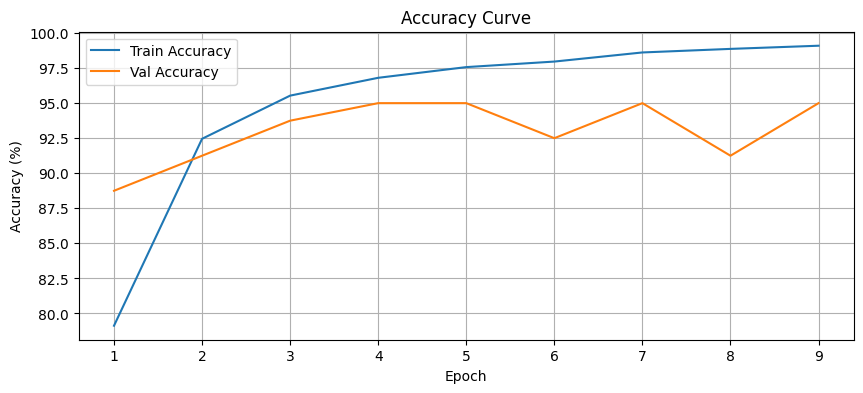

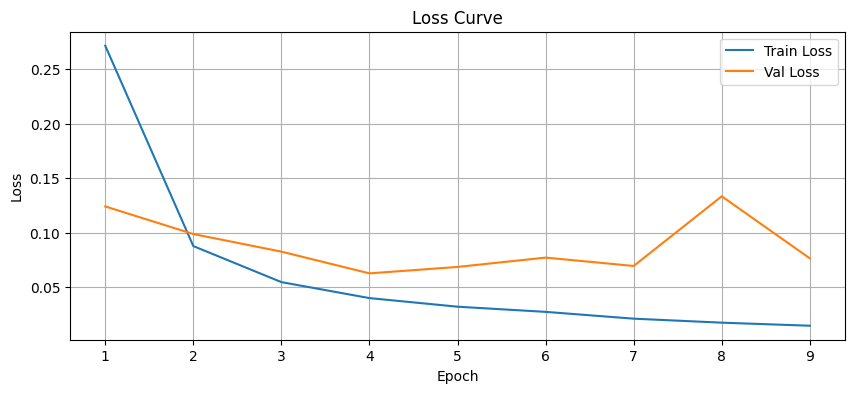

In [53]:
import matplotlib.pyplot as plt

epochs = range(1, len(onehot_train_acc_history) + 1)

plt.figure(figsize=(10, 4))
plt.plot(epochs, onehot_train_acc_history, label="Train Accuracy")
plt.plot(epochs, onehot_val_acc_history, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(epochs, onehot_train_loss_history, label="Train Loss")
plt.plot(epochs, onehot_val_loss_history, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid(True)
plt.show()


✅ Accuracy:  0.9500
✅ Precision: 0.9498
✅ Recall:    0.9500
✅ F1-Score:  0.9492




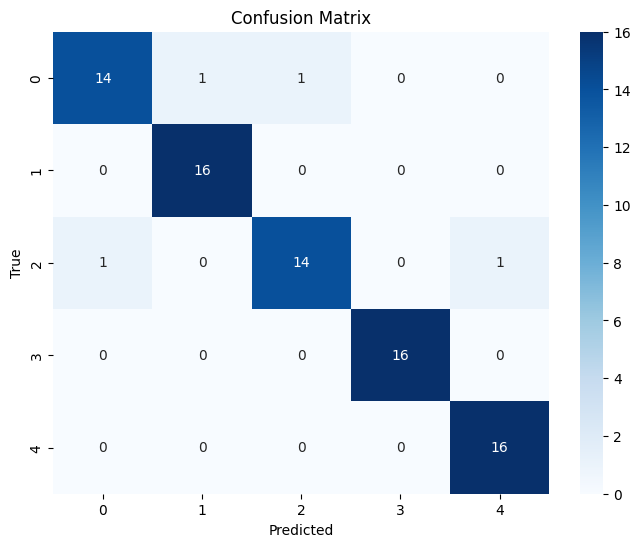



✅ AUC Score (OVR): 0.9943




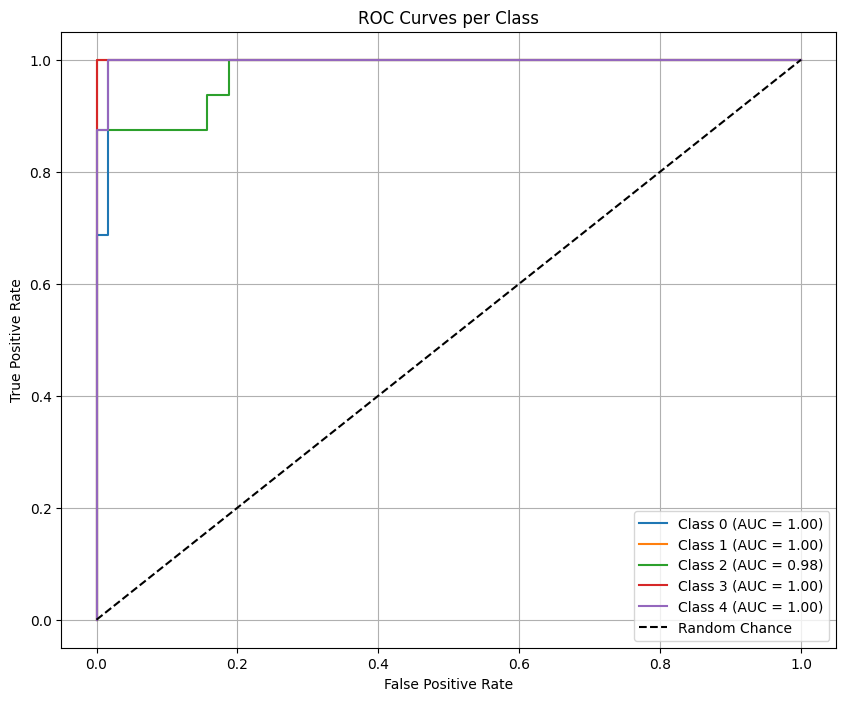

In [54]:
evaluate_model_metrics(model, val_loader_oh, is_onehot=True)

######Unfreeze All

In [55]:
onehot_train_acc_history = []
onehot_val_acc_history = []
onehot_train_loss_history = []
onehot_val_loss_history = []


model = get_resnet50_model(stage="all")
optimizer = get_optimizer(model, lr=1e-5)
train_resnet(model, train_loader_oh, val_loader_oh, criterion_onehot, optimizer,
             num_epochs=10,
             train_acc_hist=onehot_train_acc_history,
             val_acc_hist=onehot_val_acc_history,
             train_loss_hist=onehot_train_loss_history,
             val_loss_hist=onehot_val_loss_history,
             patience=5)

[01] Train Acc: 47.68% | Val Acc: 72.50% | Train Loss: 0.5875 | Val Loss: 0.4859
[02] Train Acc: 78.36% | Val Acc: 81.25% | Train Loss: 0.4110 | Val Loss: 0.3018
[03] Train Acc: 85.96% | Val Acc: 88.75% | Train Loss: 0.2716 | Val Loss: 0.1911
[04] Train Acc: 88.42% | Val Acc: 92.50% | Train Loss: 0.1881 | Val Loss: 0.1457
[05] Train Acc: 90.56% | Val Acc: 92.50% | Train Loss: 0.1396 | Val Loss: 0.1193
[06] Train Acc: 91.21% | Val Acc: 92.50% | Train Loss: 0.1167 | Val Loss: 0.1109
[07] Train Acc: 91.92% | Val Acc: 92.50% | Train Loss: 0.1018 | Val Loss: 0.1006
[08] Train Acc: 93.45% | Val Acc: 92.50% | Train Loss: 0.0862 | Val Loss: 0.0975
[09] Train Acc: 94.49% | Val Acc: 92.50% | Train Loss: 0.0717 | Val Loss: 0.0879
[10] Train Acc: 94.97% | Val Acc: 91.25% | Train Loss: 0.0638 | Val Loss: 0.0847
✅ Best model restored from epoch with lowest validation loss.


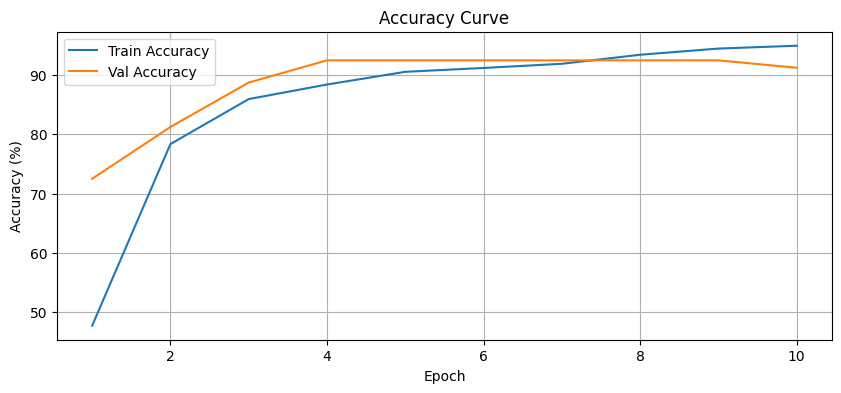

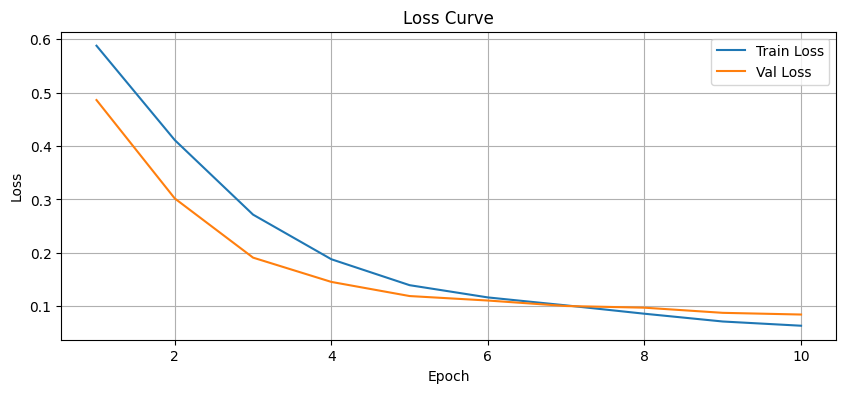

In [56]:
import matplotlib.pyplot as plt

epochs = range(1, len(onehot_train_acc_history) + 1)

plt.figure(figsize=(10, 4))
plt.plot(epochs, onehot_train_acc_history, label="Train Accuracy")
plt.plot(epochs, onehot_val_acc_history, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(epochs, onehot_train_loss_history, label="Train Loss")
plt.plot(epochs, onehot_val_loss_history, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid(True)
plt.show()


✅ Accuracy:  0.9125
✅ Precision: 0.9136
✅ Recall:    0.9125
✅ F1-Score:  0.9116




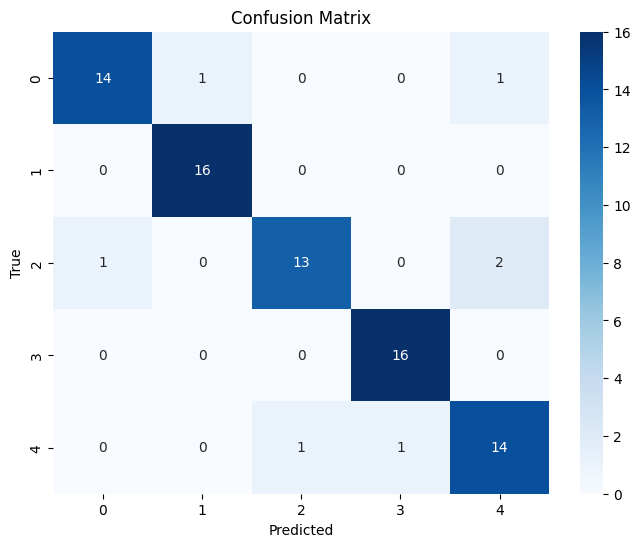



✅ AUC Score (OVR): 0.9902




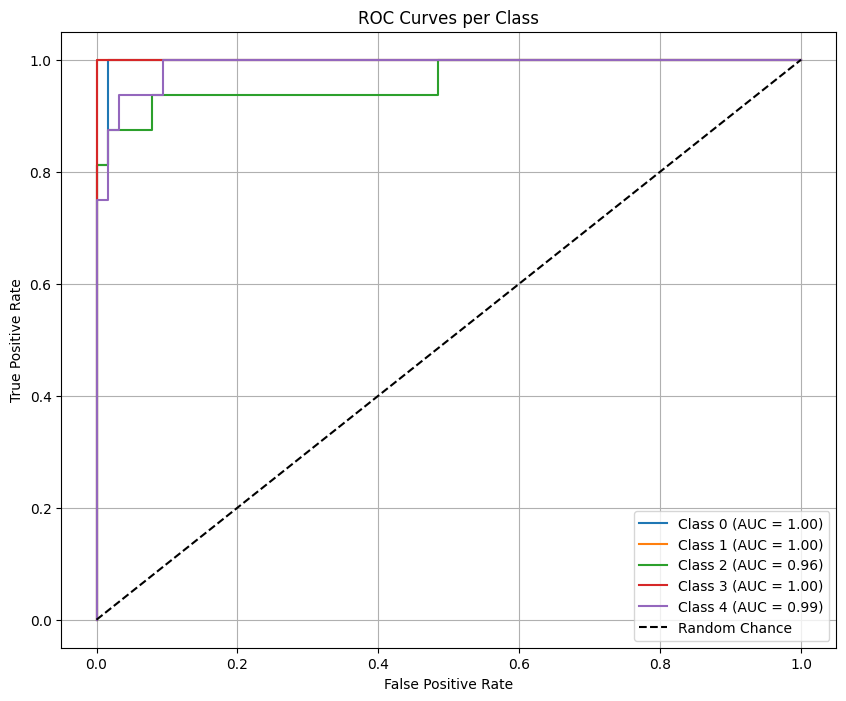

In [57]:
evaluate_model_metrics(model, val_loader_oh, is_onehot=True)

##<font color='skyblue'>Result Comparsion</font>

As observed, there was no significant difference between using label encoding and one-hot encoding(one-hot encoding has slightly better performance). It is completely okay if the performance with label encoding and one-hot encoding is similar, especially when we're using a multiclass classification model like VGG or ResNet.

Despite technical differences, both can lead to very similar decision boundaries when used correctly — especially if:
* We have well-separated classes
* There’s no multi-label overlap
* Were using compatible output layers and loss functions

One-hot encoding might show advantages if:
* We're doing multi-label classification (not just multiclass)
* We're combining outputs for multi-task models

As we can see ResNet has far more better performance in compare with VGG.

##<font color='orange'>**Task 3: RNN**</font>

### <font color='skyblue'>0. Importing Needed Libraries</font>
First, we import the needed libraries:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout, LSTM
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

Here we check the GPU availability

In [ ]:
# Check if GPU is visible
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print("GPU Device:", tf.test.gpu_device_name())

Num GPUs Available: 1
GPU Device: /device:GPU:0


### <font color='skyblue'>1. Dataset Loading</font>

Here we download and load the needed dataset:


In [ ]:
import os

if not os.path.exists("dataset_flag3"):
  !gdown 1D2_oq2qJzEeHaDPIwTrQ2DiIqucXPXiU
  !touch dataset_flag3

raw_df = pd.read_csv("BTC-USD.csv", parse_dates=["Date"])
raw_df = raw_df.drop(["Unnamed: 0"], axis=1)

# Sort by date to maintain chronological order
raw_df.sort_values("Date", inplace=True)
raw_df.reset_index(drop=True, inplace=True)

### <font color='skyblue'>2. EDA</font>

First, we print some information about the data:

In [ ]:
df = raw_df.set_index("Date")

print("\n = = = = DataFrame Info = = = = \n")
print(df.info())

print("\n = = = = First Five Rows = = = = \n")
print(df.head())

print("\n = = = = Missing Values = = = = \n")
print(df.isnull().sum())

print("\n = = = = Summary Statistics = = = = \n")
print(df.describe())


 = = = = DataFrame Info = = = = 

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3222 entries, 2014-09-17 to 2023-07-13
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    3222 non-null   float64
 1   High    3222 non-null   float64
 2   Low     3222 non-null   float64
 3   Close   3222 non-null   float64
 4   Volume  3222 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 151.0 KB
None

 = = = = First Five Rows = = = = 

                  Open        High         Low       Close    Volume
Date                                                                
2014-09-17  465.864014  468.174011  452.421997  457.334015  21056800
2014-09-18  456.859985  456.859985  413.104004  424.440002  34483200
2014-09-19  424.102997  427.834991  384.532013  394.795990  37919700
2014-09-20  394.673004  423.295990  389.882996  408.903992  36863600
2014-09-21  408.084991  412.425995  393.181000  398.821014  26580100

 = = 

As you can see, there is no missing values in the dataset, and we have the information for 3222 entries. Between these features, open, low, high and close likely follow close distributions, as their mean, max, min and std are so close together. In contrast, volume seems to be very different from the other features in terms of statistics and distribution.

Next, we plot the OHLCV, to gain some visual insights about the data:

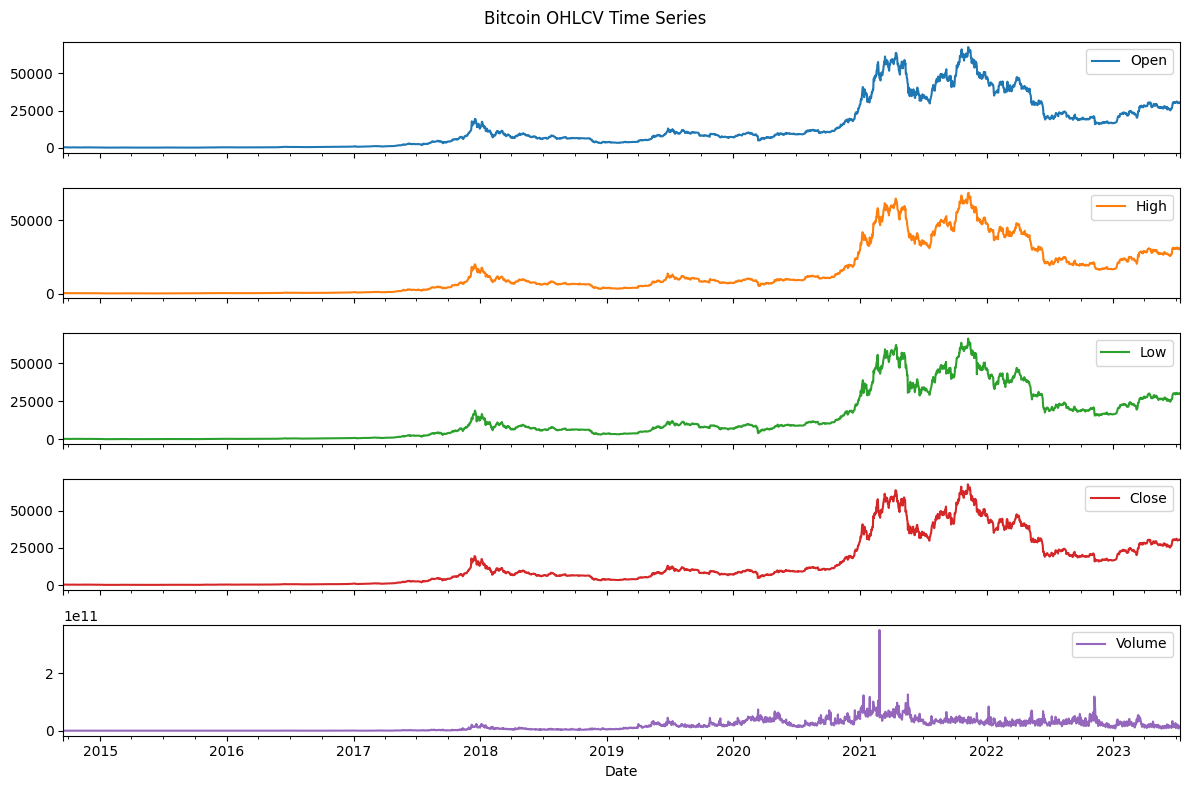

In [ ]:
df.plot(subplots=True, figsize=(12, 8), title="Bitcoin OHLCV Time Series")
plt.tight_layout()
plt.show()

These visualizations support our former hypothesis about the data, with the 4 features of open, close, high and low following simmilar patterns and the volume following a completely different course, leading to meaningful differences with the other features.

Here we plot the distribution of these features:

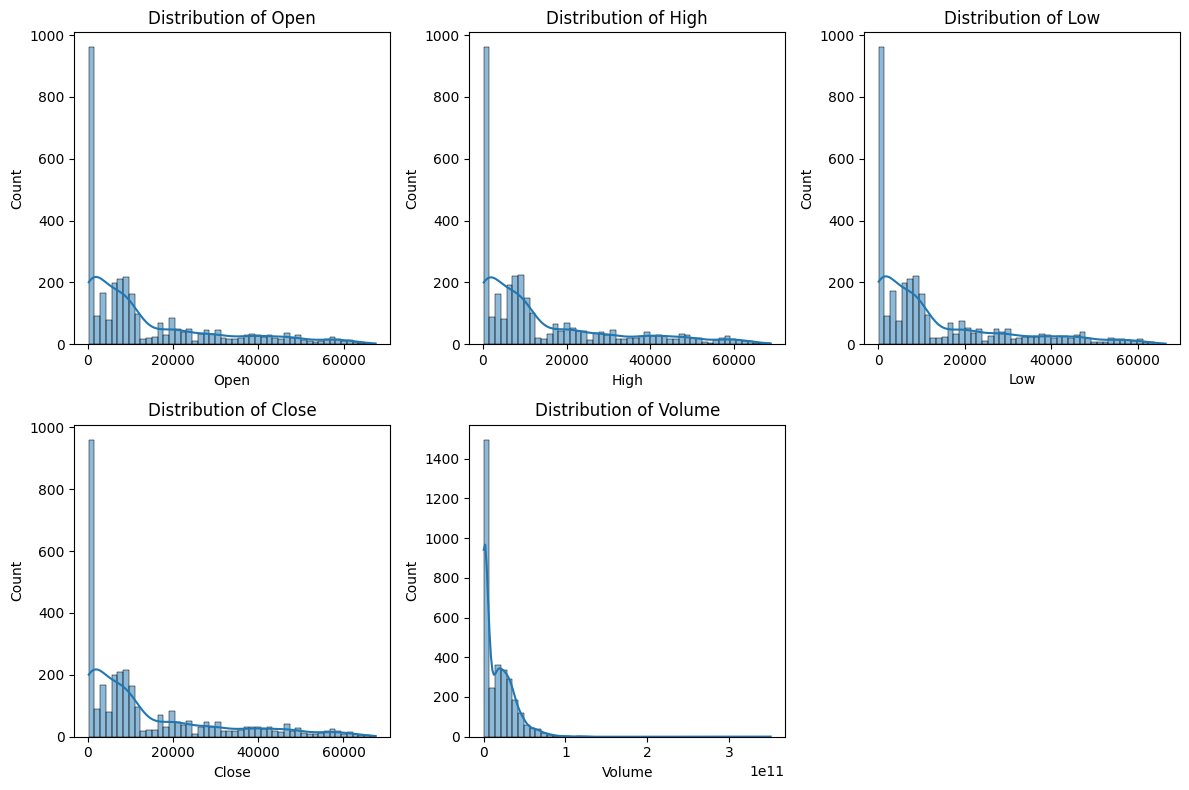

In [ ]:
plt.figure(figsize=(12, 8))
for i, col in enumerate(df.columns):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

In all price-related charts (Open, High, Low, Close), the majority of values are clustered at the lower end, indicating that most trades occurred at relatively low prices, while very high price values are rare. Similarly, the Volume chart shows that most trading days had low trading volumes, with only a few days experiencing extremely high spikes. All distributions are right-skewed, meaning that the data is concentrated on the left with a long tail extending to the right. These plots furthur support our initial guess about the distribution of the these features.

In this step, we plot the correlation heatmap:

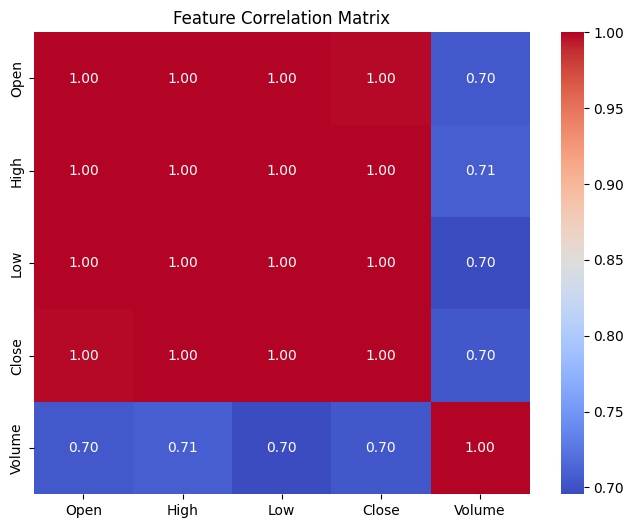

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

As you can see, Open, High, Low, and Close are all perfectly correlated with each other (correlation = 1.00), meaning they move together very closely—this is expected in financial datasets, as these prices are part of the same daily trading data. However, Volume is less correlated with these prices (correlation around 0.70–0.71), indicating that trading volume doesn’t always rise or fall with price changes. The heatmap itself looks intense because the upper 4 features are so tightly correlated that they saturate the color scale, making only the volume correlations stand out.

### <font color='skyblue'>3. Data Processing</font>

Feature Engineering: We'll define the target as the volitality (std of log returns) over 10 days

In [ ]:
close_prices = df["Close"]
log_returns = np.log(close_prices / close_prices.shift(1))
volatility = log_returns.rolling(window=10).std().shift(1)
df["Target"] = volatility
df.dropna(inplace=True)

Next we do train/Test split and MinMax scale. We also add some new features to handle the problem of initial values being so small comparing with the latter values (we add difference of returns of all the features):

In [ ]:
for col in ["Open", "High", "Low", "Close", "Volume"]:
    df[f"{col}_ret"] = df[col].shift(1) / df[col].shift(2) - 1


feature_cols = [f"{col}_ret" for col in ["Open", "High", "Low", "Close", "Volume"]]

df.dropna(inplace=True)

df = df[(df[feature_cols] != 0).all(axis=1)]

split = int(0.8 * len(df))
df_train = df.iloc[:split]
df_test = df.iloc[split:]

X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_train_scaled = X_scaler.fit_transform(df_train[feature_cols])
X_test_scaled = X_scaler.transform(df_test[feature_cols])

y_train = y_scaler.fit_transform(df_train["Target"].values.reshape(-1, 1))
y_test = y_scaler.transform(df_test["Target"].values.reshape(-1, 1))

Here we create Sequences for RNN:

In [ ]:
def create_sequences(X, y, lookback):
    seqs, tgs = [], []
    for i in range(len(X) - lookback):
        seqs.append(X[i:i+lookback])
        tgs.append(y[i+lookback-1])
    return np.array(seqs), np.array(tgs)

LOOK_BACK = 60

X_train_val, y_train_val = create_sequences(X_train_scaled, y_train, LOOK_BACK)
X_test, y_test = create_sequences(X_test_scaled,  y_test,  LOOK_BACK)

Now we do train/Validation Split

In [ ]:
train_val_size = int(0.8 * len(X_train_val))

X_train = X_train_val[:train_val_size]
y_train = y_train_val[:train_val_size]

X_val = X_train_val[train_val_size:]
y_val = y_train_val[train_val_size:]

### <font color='skyblue'>Building the RNN</font>



```
# This is formatted as code
```

In this part we build the Model. I has 4 simple RNN layers, with each 2 layers having one dropout layer for regularization porpuses:

In [ ]:
model = Sequential([
    SimpleRNN(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    SimpleRNN(64, return_sequences=True),
    Dropout(0.1),
    SimpleRNN(64, return_sequences=True),
    SimpleRNN(32, return_sequences=False),
    Dropout(0.1),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1)
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Now we compile the Model. We use mse as a typical loss function for RNN, and we use ADAM with learning rate of 0.0001, which was obtained empirically.

In [ ]:
model.compile(
    loss='mse',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    metrics=['mae']
)

And now we train the Model for 100 epoches:

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 139ms/step - loss: 0.0729 - mae: 0.2145 - val_loss: 0.0078 - val_mae: 0.0699
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0476 - mae: 0.1718 - val_loss: 0.0100 - val_mae: 0.0786
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0386 - mae: 0.1506 - val_loss: 0.0081 - val_mae: 0.0712
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0280 - mae: 0.1297 - val_loss: 0.0106 - val_mae: 0.0813
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0284 - mae: 0.1281 - val_loss: 0.0081 - val_mae: 0.0715
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0233 - mae: 0.1162 - val_loss: 0.0083 - val_mae: 0.0723
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0219 - mae: 0.1145 - val_loss: 0.0096 - val_mae: 0.0771
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0225 - mae: 0.1127 - val_loss: 0.0077 - val_mae: 0.0696
Epoch 9/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - 

Here we evaluate on Test Set

In [ ]:
test_loss, test_mae = model.evaluate(X_test, y_test)
print(f"Test MSE: {test_loss:.6f}, Test MAE: {test_mae:.6f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0024 - mae: 0.0372
Test MSE: 0.002415, Test MAE: 0.037074


And plot Training History

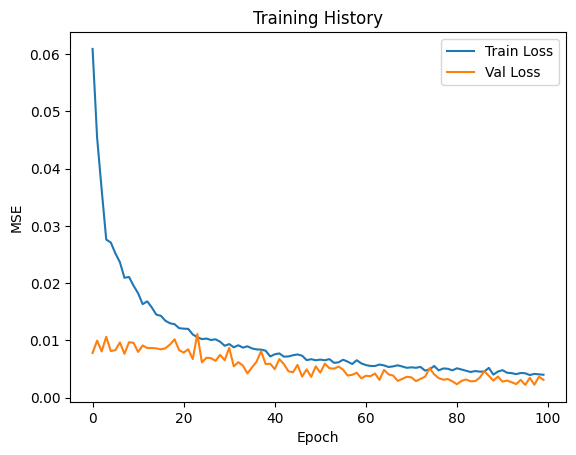

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.title('Training History')
plt.show()

### <font color='skyblue'>Evaluation and Visualizations</font>

Here we do the predections using our trained model and inverse scale the answers:

In [ ]:
y_train_pred_scaled = model.predict(X_train)
y_test_pred_scaled = model.predict(X_test)

y_train_pred = y_scaler.inverse_transform(y_train_pred_scaled).flatten()
y_test_pred = y_scaler.inverse_transform(y_test_pred_scaled).flatten()

y_train_true = y_scaler.inverse_transform(y_train).flatten()
y_test_true = y_scaler.inverse_transform(y_test).flatten()

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step


Next, we calculate the metrics:

In [ ]:
# --- MSE, RMSE, MAE ---
mse = mean_squared_error(y_test_true, y_test_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_true, y_test_pred)

# --- MAPE ---
mape = mean_absolute_percentage_error(y_test_true, y_test_pred)

# --- Cumulative Error (CE) ---
ce = np.sum(y_test_pred - y_test_true)

print(f"Test MSE : {mse:.6f}")
print(f"Test RMSE: {rmse:.6f}")
print(f"Test MAE : {mae:.6f}")
print(f"Test MAPE: {mape:.2%}")
print(f"Cumulative Error (CE): {ce:.6f}")


Test MSE : 0.000069
Test RMSE: 0.008303
Test MAE : 0.006264
Test MAPE: 24.55%
Cumulative Error (CE): -2.488547


And plot the actual and predicted values:

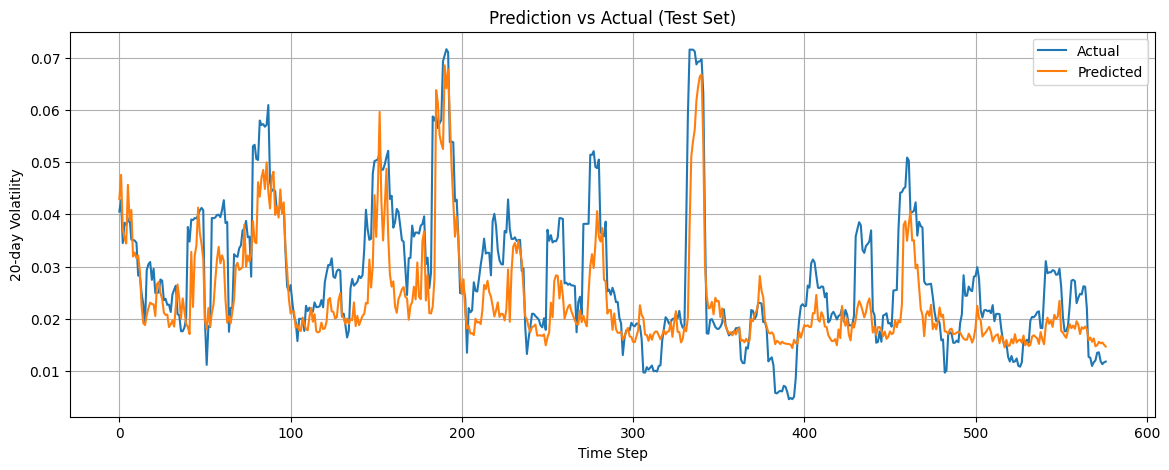

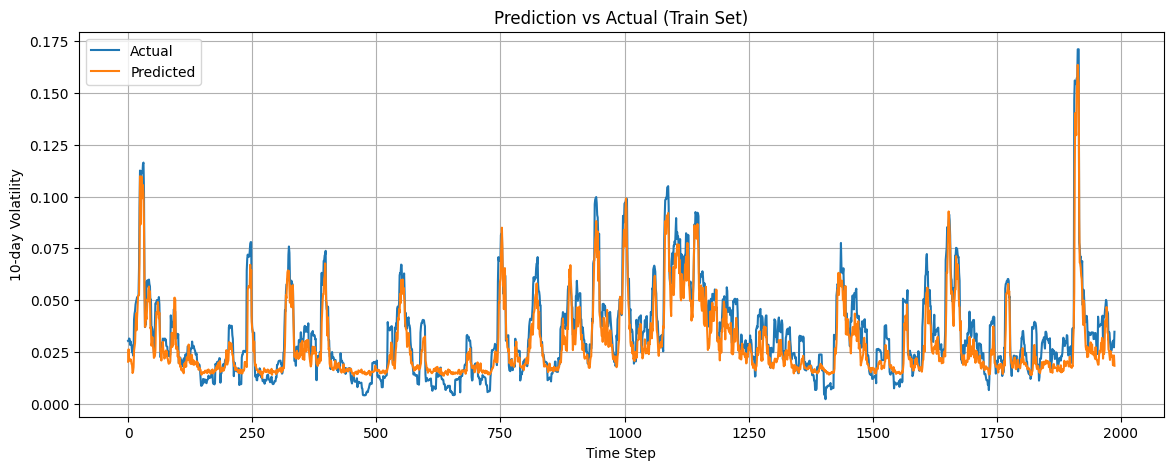

In [ ]:
# Plot test set
plt.figure(figsize=(14, 5))
plt.plot(y_test_true, label='Actual')
plt.plot(y_test_pred, label='Predicted')
plt.title('Prediction vs Actual (Test Set)')
plt.xlabel('Time Step')
plt.ylabel('20-day Volatility')
plt.legend()
plt.grid(True)
plt.show()

# Plot train set (optional)
plt.figure(figsize=(14, 5))
plt.plot(y_train_true, label='Actual')
plt.plot(y_train_pred, label='Predicted')
plt.title('Prediction vs Actual (Train Set)')
plt.xlabel('Time Step')
plt.ylabel('10-day Volatility')
plt.legend()
plt.grid(True)
plt.show()

Finally, prediction error over time:

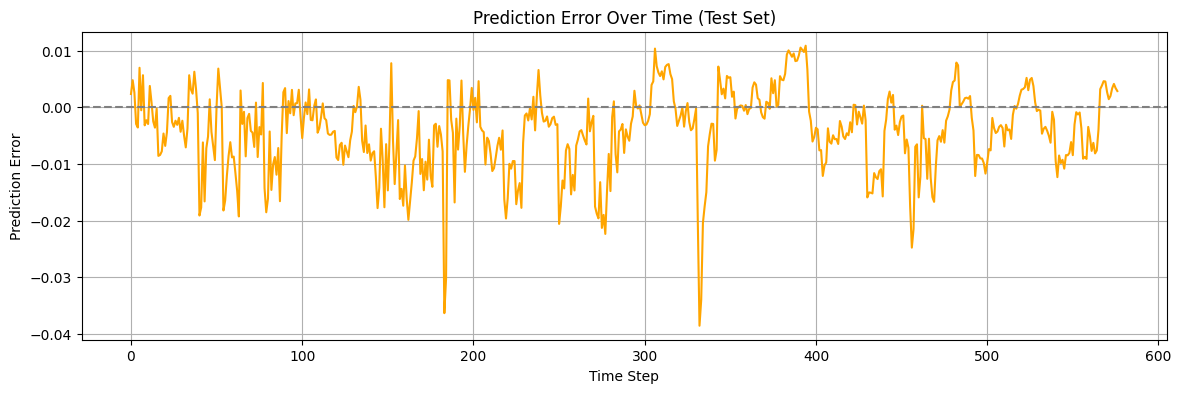

In [ ]:
# Compute residuals
error_test = y_test_pred - y_test_true

plt.figure(figsize=(14, 4))
plt.plot(error_test, color='orange')
plt.axhline(0, color='gray', linestyle='--')
plt.title('Prediction Error Over Time (Test Set)')
plt.xlabel('Time Step')
plt.ylabel('Prediction Error')
plt.grid(True)
plt.show()

### <font color='skyblue'>LSTM</font>

We do the exact same steps, this time for LSTM:

Epoch 1/150


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - loss: 0.0283 - mae: 0.1213 - val_loss: 0.0079 - val_mae: 0.0706
Epoch 2/150
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0183 - mae: 0.0981 - val_loss: 0.0078 - val_mae: 0.0704
Epoch 3/150
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0172 - mae: 0.0974 - val_loss: 0.0089 - val_mae: 0.0742
Epoch 4/150
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0181 - mae: 0.0976 - val_loss: 0.0079 - val_mae: 0.0705
Epoch 5/150
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0189 - mae: 0.1007 - val_loss: 0.0080 - val_mae: 0.0708
Epoch 6/150
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0172 - mae: 0.0986 - val_loss: 0.0085 - val_mae: 0.0727
Epoch 7/150
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0176 - mae: 0.0962 - val_loss: 0.0078 - val_mae: 0.0706
Epoch 8/150
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0182 - mae: 0.0997 - val_loss: 0.0079 - val_mae: 0.0707
Epoch 9/150
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0192 -

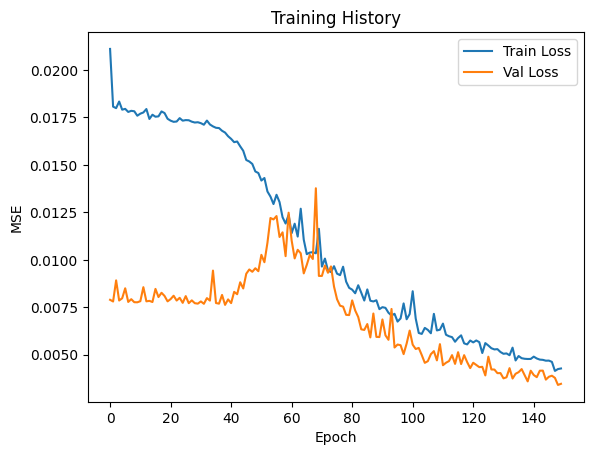

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Test MSE : 0.000088
Test RMSE: 0.009356
Test MAE : 0.007264
Test MAPE: 33.54%
Cumulative Error (CE): 1.568508


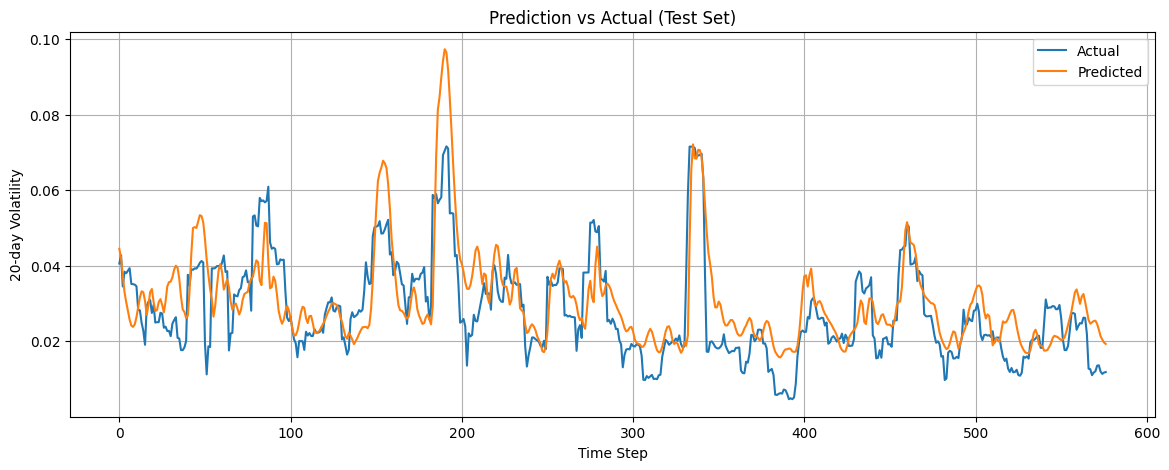

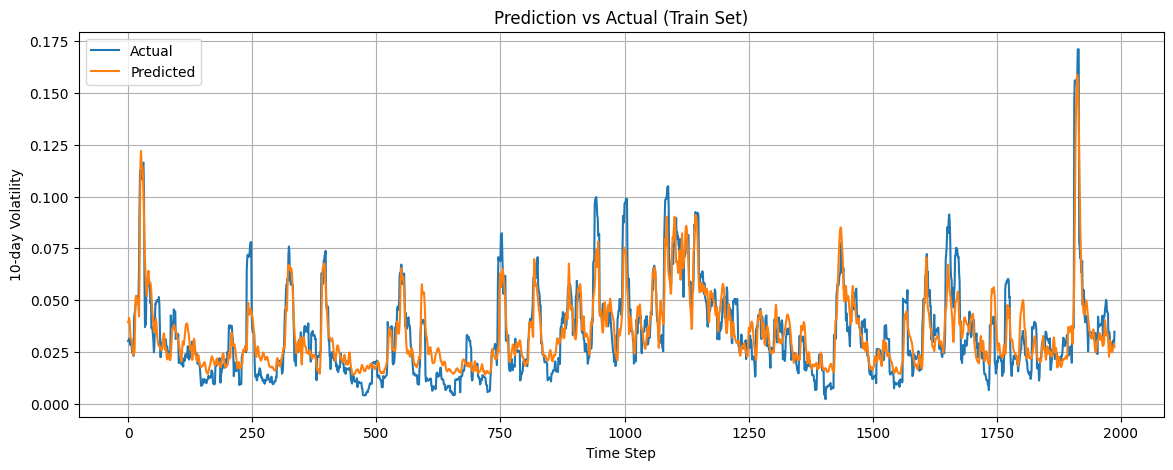

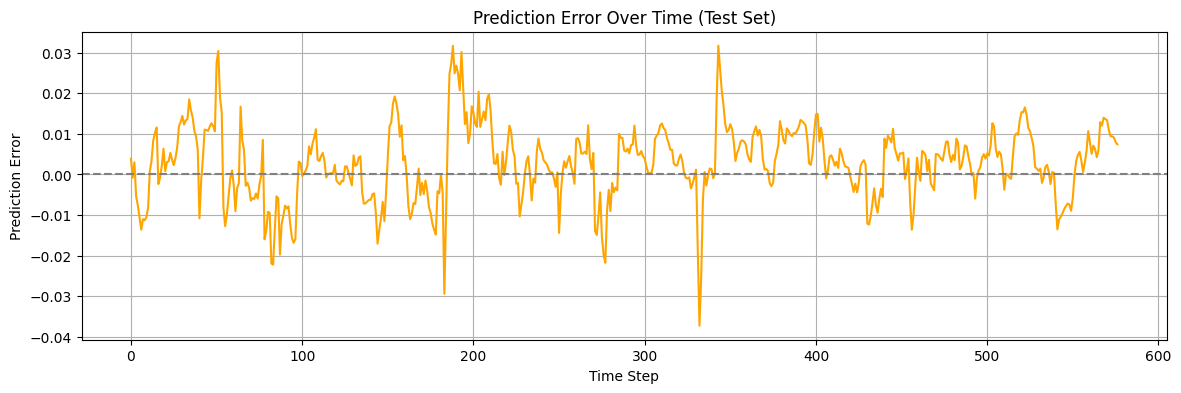

In [ ]:
# ========================
# Model Definition
# ========================

model = Sequential([    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(128, return_sequences=True),
    Dropout(0.1),
    LSTM(128, return_sequences=True),
    LSTM(64, return_sequences=False),
    Dropout(0.1),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1)
])

# ========================
# Compilation
# ========================

model.compile(
    loss='mse',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    metrics=['mae']
)

# ========================
# Model Training
# ========================

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=32,
    verbose=1
)

# ========================
# Evaluate on Test Set
# ========================

test_loss, test_mae = model.evaluate(X_test, y_test)
print(f"Test MSE: {test_loss:.6f}, Test MAE: {test_mae:.6f}")

# ========================
# Plot Training History
# ========================

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.title('Training History')
plt.show()

# ========================
# Model Predictions (Rescaled)
# ========================

# Predict on training and test sets
y_train_pred_scaled = model.predict(X_train)
y_test_pred_scaled = model.predict(X_test)

# Inverse transform predictions and ground truth to original scale
y_train_pred = y_scaler.inverse_transform(y_train_pred_scaled).flatten()
y_test_pred = y_scaler.inverse_transform(y_test_pred_scaled).flatten()

y_train_true = y_scaler.inverse_transform(y_train).flatten()
y_test_true = y_scaler.inverse_transform(y_test).flatten()

# ========================
# Evaluation Metrics
# ========================

mse = mean_squared_error(y_test_true, y_test_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_true, y_test_pred)
mape = mean_absolute_percentage_error(y_test_true, y_test_pred)
ce = np.sum(y_test_pred - y_test_true)

print(f"Test MSE : {mse:.6f}")
print(f"Test RMSE: {rmse:.6f}")
print(f"Test MAE : {mae:.6f}")
print(f"Test MAPE: {mape:.2%}")
print(f"Cumulative Error (CE): {ce:.6f}")

# ========================
# Visualization: Test Predictions
# ========================

plt.figure(figsize=(14, 5))
plt.plot(y_test_true, label='Actual')
plt.plot(y_test_pred, label='Predicted')
plt.title('Prediction vs Actual (Test Set)')
plt.xlabel('Time Step')
plt.ylabel('20-day Volatility')
plt.legend()
plt.grid(True)
plt.show()

# ========================
# Visualization: Train Predictions (Optional)
# ========================

plt.figure(figsize=(14, 5))
plt.plot(y_train_true, label='Actual')
plt.plot(y_train_pred, label='Predicted')
plt.title('Prediction vs Actual (Train Set)')
plt.xlabel('Time Step')
plt.ylabel('10-day Volatility')
plt.legend()
plt.grid(True)
plt.show()

# ========================
# Visualization: Prediction Residuals
# ========================

error_test = y_test_pred - y_test_true

plt.figure(figsize=(14, 4))
plt.plot(error_test, color='orange')
plt.axhline(0, color='gray', linestyle='--')
plt.title('Prediction Error Over Time (Test Set)')
plt.xlabel('Time Step')
plt.ylabel('Prediction Error')
plt.grid(True)


As you can see, the performance of LSTM is roughly the same as simple RNN, with the difference that it is capturing lows and highs better than the simple RNN, leading to predicting a wider range of target values comparing with simple RNN, probably duo to not suffering from problems like vanishing gradient.

## **<font color='Orange'>Bonus Questions</font>**

### <font color='skyblue'>Question 1</font>

<font color='skyblue'>Under what conditions is MLP equivalent to Logistic Regression?</font>

The MLP must have only one, linear input layer and one output layer with sigmoid activation function, that way our model will mathematicaly work as below:

$$\hat y =σ(w^T
 x+b)$$

 which is same as logistic regression.

 - Similar to logistic regression for multiclass classification task our output activation function should be softmax instead of sigmoid.

### <font color='skyblue'>Question 2</font>

<font color='skyblue'>Suppose you have a CNN that begins by taking an input image of size 28 × 28 × 3
and passing through a convolution layer that convolves the image using 3 filters of
dimensions 2 × 2 × 3 with valid padding.

A. How many learnable parameters does this convolution layer have?</font>

<font color='skyblue'>B. Suppose that you instead decided to use a fully connected layer to replicate the behavior of this convolutional layer. How many parameters would that fully
connected layer have?</font>

#### A. Number of Learnable Parameters in the Convolution Layer

We begin with a convolutional neural network (CNN) that takes an input image of size **28 × 28 × 3**. The first layer is a **convolutional layer** that uses:

- 3 filters (kernels)  
- Filter dimensions: $2 \times 2 \times 3$  
- Padding: Valid (i.e., no padding)  
- Stride: Not mentioned, so assumed to be 1 (default)

##### Parameter Calculation

Each filter operates on a local region of the input image and has its own set of learnable weights and a bias term. For a filter of size $2 \times 2 \times 3$:

- Number of **weights per filter** = $2 \times 2 \times 3 = 12$  
- Each filter also has **1 bias term**  
- So, total **parameters per filter** = $12 + 1 = 13$

With 3 filters, the total number of learnable parameters is:

$$
\text{Total parameters} = 3 \times 13 = \boxed{39 \text{ parameters}}
$$

---

#### B. Number of Parameters in an Equivalent Fully Connected Layer

To highlight the efficiency of convolutional layers, we now analyze what it would take to replicate the same behavior using a fully connected (dense) layer.

##### Convolution Layer Output Size

The output size of the convolution layer is computed using the formula for valid padding:

$$
\text{Output size} = \left\lfloor \frac{N - F}{S} \right\rfloor + 1
$$

where $N = 28$, $F = 2$, and $S = 1$. So:

$$
\text{Output dimension per axis} = \left\lfloor \frac{28 - 2}{1} \right\rfloor + 1 = 27
$$

Since there are 3 filters, the full output shape is:

$$
27 \times 27 \times 3 = 2187 \text{ values}
$$

##### Fully Connected Layer Design

The fully connected layer must:

- Take the entire input image as a flat vector:  
  $28 \times 28 \times 3 = 2352$ input features  
- Produce an output vector of size 2187

##### Parameter Calculation

Each of the 2187 output neurons connects to all 2352 inputs and has a bias term:

- Weights: $2352 \times 2187 = 5,\!137,\!464$  
- Biases: $2187$

$$
\text{Total parameters} = 5,\!137,\!464 + 2187 = \boxed{5,\!139,\!651 \text{ parameters}}
$$

### <font color='skyblue'>Question 3 </font>

<font color='skyblue'>Explain mathematically the vanishing gradient problem in Recurrent Neural Networks (RNNs). Then, analyze how changing the lookback window size impacts the severity of this phenomenon.</font>

#### 1.  Mathematical origin of the vanishing-gradient problem

Consider a vanilla RNN unrolled in time:

$$
h_t = \phi(W_h\,h_{t-1} + W_x\,x_t + b),\qquad
y_t = g(W_y\,h_t + c),
$$

where \$\phi(\cdot)\$ is a point-wise non-linearity (e.g.\ \$\tanh\$).

During back-propagation through time (BPTT) the gradient of the loss \$L\$ at the final step \$T\$ w\.r.t.\ some earlier hidden state \$h\_k\$ (\$k\<T\$) is

$$
\frac{\partial L}{\partial h_k}
  \;=\;
  \frac{\partial L}{\partial h_T}\;
  \prod_{t=k+1}^{T}
  \Bigl(
        \underbrace{\,\mathrm{diag}\!\bigl(\phi'(a_t)\bigr)}_{\text{element-wise $\phi'$}}
        \,W_h
  \Bigr),
\qquad a_t = W_h\,h_{t-1} + W_x\,x_t + b.
$$

Let \$|\cdot|\$ be any sub-multiplicative matrix norm and denote

\$\rho \equiv |\mathrm{diag}(\phi')| \le 1\$ (because \$\phi' \in \[0,1]\$ for \$\tanh\$ or \$\mathrm{sigmoid}\$)
and \$\sigma \equiv |W\_h|\$ (spectral norm of the recurrent weight matrix).

Bounding the gradient norm:

$$
\Bigl\|
\frac{\partial L}{\partial h_k}
\Bigr\|
\;\le\;
\Bigl\|
\frac{\partial L}{\partial h_T}
\Bigr\|\;
(\rho\,\sigma)^{\,T-k}.
$$

If \$\rho,\sigma < 1\$, the factor \$(\rho,\sigma)^{T-k}\$ **decays exponentially** with the temporal distance \$(T-k)\$, driving the gradient toward zero — the classical *vanishing-gradient* effect.
If \$\rho,\sigma > 1\$, the product instead explodes, yielding the *exploding-gradient* counterpart.

---

#### 2.  Impact of the look-back window (sequence length)

In practice we do not always back-propagate through the entire sequence; we choose a **truncation length** or **look-back window** \$L\_{\text{BPTT}}\$:

$$
L_{\text{BPTT}} = T - k_{\min},
$$

and only unroll that many steps.  Substituting \$L\_{\text{BPTT}}\$ for \$(T-k)\$ in the bound above gives

$$
\Bigl\|
\frac{\partial L}{\partial h_{T-L_{\text{BPTT}}}}
\Bigr\|
\;\le\;
\Bigl\|
\frac{\partial L}{\partial h_T}
\Bigr\|\;
(\rho\,\sigma)^{\,L_{\text{BPTT}}}.
$$

**Hence the severity of vanishing gradients depends exponentially on the chosen window:**

| Look-back window \$L\_{\text{BPTT}}\$ | Gradient factor \$(\rho,\sigma)^{L\_{\text{BPTT}}}\$ | Practical effect                                                                                |
| ------------------------------------- | ---------------------------------------------------- | ----------------------------------------------------------------------------------------------- |
| Short (e.g.\ 10–20 steps)             | Close to \$1\$                                       | Gradients propagate; model can learn short-term patterns.                                       |
| Moderate (50–100)                     | Noticeable decay                                     | Harder to train; careful weight initialisation or gating helps.                                 |
| Long (200+ steps)                     | Near-zero (or exploding)                             | Vanilla RNN effectively forgets early timesteps; LSTM/GRU or skip-connections become necessary. |

---

#### 3.  Take-aways for model design

* **Longer look-back windows amplify** the vanishing-gradient problem geometrically in vanilla RNNs.
* Choosing a **truncated BPTT length** trades off memory of long-range dependencies against stable training.
* Architectures with *gates* (LSTM, GRU), *skip connections*, *attention*, or *unitary/orthogonal* recurrent matrices keep \$\rho,\sigma\$ closer to \$1\$, letting you use larger windows without gradient collapse.
